# March Machine Learning Mania 2026 — Pipeline

## Complete architecture with all data sources integrated

| Component | Detail |
|-----------|--------|
| **Anti-timeout** | JavaScript keep-alive runs automatically on Colab free tier |
| **KenPom** | Paid — scraped automatically with your credentials |
| **Barttorvik** | Free — scraped automatically, no login needed |
| **Vegas odds** | Your `vegas_odds_2026.csv` — market's collective intelligence |
| **Internal features** | Elo, Bradley-Terry, tempo-free, time-decay, seeds, Massey, conf tournament, coaches |
| **Models** | LR + XGBoost (higher weight) + CatBoost — lean 3-model stack |
| **Tuning** | Optuna Bayesian optimisation (60+50 trials) |
| **Folds** | 8 Leave-One-Season-Out folds — only correct CV for time-series data |
| **Calibration** | Isotonic + Beta + Bayesian Beta-prior — auto-selects best per gender |
| **Metric** | Brier Score + Brier Skill Score (Wikipedia decomposition) |


## ⏰ Cell 1 — Anti-Timeout (Run This First!)



In [1]:
# ══════════════════════════════════════════════════════════════════
# ANTI-TIMEOUT FOR GOOGLE COLAB FREE TIER
#
# Colab disconnects after ~90 minutes of no interaction.
# This JavaScript snippet simulates a click every 60 seconds,
# which prevents the "Your session is about to end" popup.
#
# HOW IT WORKS:
#   - Injects a <script> tag into the Colab page DOM
#   - setInterval runs a function every 60,000ms (60 seconds)
#   - The function clicks the "Connect" button to signal activity
#   - Runs silently in the background — you won't see anything
# ══════════════════════════════════════════════════════════════════

from IPython.display import display, Javascript

# Inject the keep-alive script into the browser page
keep_alive_js = Javascript('''
    // Keep-alive: click the Colab connect button every 60 seconds
    // This prevents the free-tier idle disconnection
    function keepAlive() {
        // Try to find and click the connect button
        var connectButton = document.querySelector(
            'colab-connect-button, paper-button[id="connect"]'
        );
        if (connectButton) {
            connectButton.click();
        }
        // Also simulate a key event to signal activity
        document.dispatchEvent(new KeyboardEvent('keydown', {key: 'Control'}));
        console.log('Keep-alive ping sent at: ' + new Date().toLocaleTimeString());
    }

    // Run every 60 seconds (60000 milliseconds)
    var keepAliveInterval = setInterval(keepAlive, 60000);

    console.log('✅ Keep-alive script started — pings every 60 seconds');
    console.log('   Your Colab session is now protected from timeout.');
''')

display(keep_alive_js)

print("✅ Anti-timeout script injected into browser!")
print("   Pings every 60 seconds to prevent Colab disconnection.")
print("   You can now safely run all remaining cells.")
print()
print("   NOTE: This only works while your browser tab is open.")
print("   If you close the tab, the keep-alive stops.")

<IPython.core.display.Javascript object>

✅ Anti-timeout script injected into browser!
   Pings every 60 seconds to prevent Colab disconnection.
   You can now safely run all remaining cells.

   NOTE: This only works while your browser tab is open.
   If you close the tab, the keep-alive stops.


## 📦 Cell 2 — Install Libraries

In [2]:
# ══════════════════════════════════════════════════════════════════
# INSTALL ALL REQUIRED LIBRARIES
#
# xgboost    : gradient boosting (our strongest model)
# catboost   : symmetric tree boosting (best on small datasets)
# scikit-learn: LR, calibration, metrics, preprocessing
# optuna     : Bayesian hyperparameter optimisation
# requests   : HTTP requests for KenPom/Barttorvik scraping
# beautifulsoup4: HTML parsing for web scraping
# ══════════════════════════════════════════════════════════════════

!pip install -q xgboost catboost scikit-learn optuna requests beautifulsoup4 --upgrade
print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
✅ All libraries installed successfully!


## 📚 Cell 3 — Import Libraries

In [3]:
# ══════════════════════════════════════════════════════════════════
# IMPORT ALL LIBRARIES
# ══════════════════════════════════════════════════════════════════

# Core data manipulation
import numpy as np
import pandas as pd
import os, re, copy, warnings, io, time, json
warnings.filterwarnings('ignore')   # suppress non-critical warnings

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Machine learning — our 3 chosen models
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

# Our 3 models (see Cell 12 for why exactly these 3)
from xgboost import XGBClassifier      # strongest non-linear model
from catboost import CatBoostClassifier # best on small datasets

# Bayesian hyperparameter optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress trial output

# Mathematical tools for calibration
from scipy.special import expit, logit   # sigmoid and inverse sigmoid
from scipy.optimize import minimize       # numerical optimisation

# Google Colab file upload/download
from google.colab import files

# Set random seed for reproducibility
np.random.seed(42)

print("✅ All imports successful!")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")

✅ All imports successful!
   NumPy   : 2.0.2
   Pandas  : 2.2.2


## ⚙️ Cell 4 : Configuration



In [ ]:
# ══════════════════════════════════════════════════════════════════
# CONFIGURATION — EDIT THESE VALUES BEFORE RUNNING
# ══════════════════════════════════════════════════════════════════

# ── KenPom (paid subscription at kenpom.com — $20/year) ───────────
USE_KENPOM  = True             # Set True when you have a subscription
KENPOM_USER = "replace your email here"               # ← your kenpom.com email here
KENPOM_PASS = "replace your password here"               # your kenpom.com password here

# ── Barttorvik T-Rank (completely FREE, no login needed) ──────────
# Scraped automatically. Provides Barthag, AdjO, AdjD, AdjT.
USE_BARTTORVIK = True

# ── Season settings ───────────────────────────────────────────────
# Training seasons: we use 2016-2025 tournament games as labels.
# Going back to 2016 gives us ~630 men's training samples.
# Earlier seasons have less reliable advanced stats.
TRAIN_SEASONS  = list(range(2016, 2026))
TARGET_SEASON  = 2026    # the season we are predicting

# ── Optuna tuning ─────────────────────────────────────────────────
# Number of Optuna trials per model.
# More trials = better params but longer runtime.
# 60+50 = ~15-20 minutes total. Reduce if session times out.
XGB_TRIALS = 60
CAT_TRIALS = 50

# ── Ensemble blend weights ────────────────────────────────────────
# XGBoost gets higher weight based on competition winner analysis
# showing XGBoost outperforms CatBoost and LR on this dataset.
# Weights are then further refined by Optuna CV scores.
XGB_BASE_WEIGHT = 0.50   # XGBoost — highest weight
CAT_BASE_WEIGHT = 0.30   # CatBoost — second
LR_BASE_WEIGHT  = 0.20   # Logistic Regression — calibration anchor

# Sanity check — weights must sum to 1.0
assert abs(XGB_BASE_WEIGHT + CAT_BASE_WEIGHT + LR_BASE_WEIGHT - 1.0) < 1e-9, \
    "Blend weights must sum to 1.0!"

print("✅ Configuration set!")
print(f"   KenPom enabled    : {USE_KENPOM}")
print(f"   Barttorvik enabled: {USE_BARTTORVIK}")
print(f"   Training seasons  : {TRAIN_SEASONS[0]}–{TRAIN_SEASONS[-1]}")
print(f"   Target season     : {TARGET_SEASON}")
print(f"   Blend weights     : XGB={XGB_BASE_WEIGHT} | CAT={CAT_BASE_WEIGHT} | LR={LR_BASE_WEIGHT}")
if USE_KENPOM and (not KENPOM_USER or not KENPOM_PASS):
    print("\n  ⚠️  WARNING: Credentials are empty! Add your email/password above.")

✅ Configuration set!
   KenPom enabled    : True
   Barttorvik enabled: True
   Training seasons  : 2016–2025
   Target season     : 2026
   Blend weights     : XGB=0.5 | CAT=0.3 | LR=0.2


## 📂 Cell 5 : Upload All Data Files

### 🔴 Required (competition files):
`MRegularSeasonCompactResults.csv`, `WRegularSeasonCompactResults.csv`,
`MNCAATourneyCompactResults.csv`, `WNCAATourneyCompactResults.csv`,
`MNCAATourneySeeds.csv`, `WNCAATourneySeeds.csv`, `SampleSubmissionStage2.csv`

### 🟡 Strongly recommended:
`MRegularSeasonDetailedResults.csv`, `WRegularSeasonDetailedResults.csv`,
`MNCAATourneyDetailedResults.csv`, `WNCAATourneyDetailedResults.csv`,
`MMasseyOrdinals.csv`, `SampleSubmissionStage1.csv`,
`MConferenceTourneyGames.csv`, `WConferenceTourneyGames.csv`,
`MTeamCoaches.csv`, `MTeamConferences.csv`, `WTeamConferences.csv`, `MTeamSpellings.csv`

### 🟢 Custom files:
`vegas_odds_2026.csv` — your completed Vegas odds file (TeamID, WinProb_Vegas only)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# UPLOAD FILES FROM YOUR COMPUTER
# Select ALL files at once (hold Ctrl/Cmd to multi-select)
# ══════════════════════════════════════════════════════════════════

print("📤 Select ALL your CSV files in the upload dialog...")
print("   Hold Ctrl (Windows) or Cmd (Mac) to select multiple files at once.")
uploaded = files.upload()
print(f"\n✅ {len(uploaded)} file(s) uploaded:")
for f in sorted(uploaded.keys()):
    size_kb = len(uploaded[f]) / 1024
    print(f"   • {f}  ({size_kb:.0f} KB)")


def load_csv(name, required=True):
    """
    Load a CSV file from uploaded files or local disk.
    Returns a DataFrame, or None if the file is optional and not found.

    Parameters
    ----------
    name     : filename (e.g. 'MTeams.csv')
    required : if True, raises an error when file is missing
    """
    if name in uploaded:
        return pd.read_csv(io.BytesIO(uploaded[name]))
    elif os.path.exists(name):
        return pd.read_csv(name)
    else:
        if required:
            raise FileNotFoundError(
                f"Required file missing: {name}\n"
                f"Please upload it and re-run this cell."
            )
        print(f"   ⚠️  Optional not found: {name} (will skip)")
        return None


# ── Load required competition files ───────────────────────────────
M_reg   = load_csv('MRegularSeasonCompactResults.csv')   # Men's reg season results
W_reg   = load_csv('WRegularSeasonCompactResults.csv')   # Women's reg season results
M_tourn = load_csv('MNCAATourneyCompactResults.csv')     # Men's tourney results (our labels)
W_tourn = load_csv('WNCAATourneyCompactResults.csv')     # Women's tourney results (our labels)
M_seeds = load_csv('MNCAATourneySeeds.csv')              # Men's tournament seeds (1-16)
W_seeds = load_csv('WNCAATourneySeeds.csv')              # Women's tournament seeds
sub2    = load_csv('SampleSubmissionStage2.csv')         # 2026 matchup IDs to predict

# ── Load optional competition files ───────────────────────────────
M_reg_det    = load_csv('MRegularSeasonDetailedResults.csv',  required=False)  # men box scores
W_reg_det    = load_csv('WRegularSeasonDetailedResults.csv',  required=False)  # women box scores
M_tourn_det  = load_csv('MNCAATourneyDetailedResults.csv',    required=False)  # men tourn box
W_tourn_det  = load_csv('WNCAATourneyDetailedResults.csv',    required=False)  # women tourn box
massey       = load_csv('MMasseyOrdinals.csv',                required=False)  # 100+ rankings
sub1         = load_csv('SampleSubmissionStage1.csv',         required=False)  # for validation
M_conf_tourn = load_csv('MConferenceTourneyGames.csv',        required=False)  # conf tournament
W_conf_tourn = load_csv('WConferenceTourneyGames.csv',        required=False)  # conf tournament
coaches      = load_csv('MTeamCoaches.csv',                   required=False)  # coach history
M_conf_teams = load_csv('MTeamConferences.csv',               required=False)  # conf affiliation
W_conf_teams = load_csv('WTeamConferences.csv',               required=False)  # conf affiliation
team_spell   = load_csv('MTeamSpellings.csv',                 required=False)  # name→ID mapping

# ── Load the custom Vegas odds file ──────────────────────────────
# Format: TeamID (int), WinProb_Vegas (float between 0 and 1)
vegas_df     = load_csv('vegas_odds_2026.csv',                required=False)

print(f"\n✅ Data loading complete!")
print(f"   Men reg season  : {len(M_reg):,} games  ({M_reg['Season'].min()}–{M_reg['Season'].max()})")
print(f"   Women reg season: {len(W_reg):,} games")
print(f"   Men tourn       : {len(M_tourn):,} games  (training labels)")
print(f"   Women tourn     : {len(W_tourn):,} games  (training labels)")
print(f"   2026 matchups   : {len(sub2):,} to predict")
print(f"   Vegas odds      : {len(vegas_df) if vegas_df is not None else 0} teams loaded")

📤 Select ALL your CSV files in the upload dialog...
   Hold Ctrl (Windows) or Cmd (Mac) to select multiple files at once.


Saving kenpom_2015.csv to kenpom_2015 (1).csv
Saving kenpom_2016.csv to kenpom_2016 (1).csv
Saving kenpom_2017.csv to kenpom_2017 (1).csv
Saving kenpom_2018.csv to kenpom_2018 (1).csv
Saving kenpom_2019.csv to kenpom_2019 (1).csv
Saving kenpom_2020.csv to kenpom_2020 (1).csv
Saving kenpom_2021.csv to kenpom_2021 (1).csv
Saving kenpom_2022.csv to kenpom_2022 (1).csv
Saving kenpom_2023.csv to kenpom_2023 (1).csv
Saving kenpom_2024.csv to kenpom_2024 (1).csv
Saving kenpom_2025.csv to kenpom_2025 (1).csv
Saving kenpom_2026.csv to kenpom_2026 (1).csv
Saving vegas_odds_2026.csv to vegas_odds_2026 (1).csv
Saving MTeams.csv to MTeams (1).csv
Saving haslametrics_2026.html to haslametrics_2026 (1).html
Saving MRegularSeasonCompactResults.csv to MRegularSeasonCompactResults (1).csv
Saving MRegularSeasonDetailedResults.csv to MRegularSeasonDetailedResults (1).csv
Saving MSeasons.csv to MSeasons (1).csv
Saving MSecondaryTourneyCompactResults.csv to MSecondaryTourneyCompactResults (1).csv
Saving MSe

## Cell 6 : Vegas Odds Lookup

Builds a fast lookup dictionary: `{TeamID: win_probability}`.
Vegas lines represent the market's collective intelligence; they
already incorporate injuries, momentum, and expert analysis.


In [8]:
# ══════════════════════════════════════════════════════════════════
# BUILD VEGAS ODDS LOOKUP
#
# We convert the uploaded vegas_odds_2026.csv into a fast dict.
# For teams NOT in the file (most non-tournament teams), we default
# to 0.5 (no market signal available).
#
# The model will learn to use VegasWinProb as a feature only when
# the 'Vegas_avail' flag is 1 — this handles missing data cleanly.
# ══════════════════════════════════════════════════════════════════

vegas_dict = {}   # {TeamID (int): win_probability (float)}

if vegas_df is not None:
    for _, row in vegas_df.iterrows():
        try:
            tid  = int(row['TeamID'])
            prob = float(row['WinProb_Vegas'])
            # Validate probability is in [0, 1]
            if 0.0 <= prob <= 1.0:
                vegas_dict[tid] = prob
            else:
                print(f"   ⚠️  Invalid probability {prob} for TeamID {tid} — skipping")
        except Exception as e:
            print(f"   ⚠️  Error parsing row: {e}")
    print(f"✅ Vegas odds loaded: {len(vegas_dict)} teams")
    print(f"   Probability range: [{min(vegas_dict.values()):.4f}, {max(vegas_dict.values()):.4f}]")
    # Show some examples
    sample = list(vegas_dict.items())[:5]
    print(f"   Sample entries: {sample}")
else:
    print("ℹ️  No vegas_odds_2026.csv found — Vegas feature will be 0.5 for all teams")
    print("   Upload the file in Cell 5 to enable this feature.")

✅ Vegas odds loaded: 68 teams
   Probability range: [0.0196, 0.9990]
   Sample entries: [(1420, 0.5495), (1224, 0.495), (1400, 0.5327), (1301, 0.5122), (1250, 0.6241)]


## 🏀 Cell 7 : KenPom Scraper

Logs in and scrapes Adjusted Efficiency Margin (AdjEM), AdjO, AdjD, Luck, Tempo
for seasons 2015–2026. AdjEM is the single most predictive tournament feature.

**Requires:** kenpom.com paid subscription ($20/year). Set credentials in Cell 4.


In [37]:
# ══════════════════════════════════════════════════════════════════
# KENPOM PARSER — reads manually downloaded CSV files
#
# Reads kenpom_2015.csv through kenpom_2026.csv that you uploaded.
# Handles the KenPom CSV format including:
#   - \xa0 non-breaking spaces in team names
#   - Seed numbers appended to team names (e.g. "Duke\xa01")
#   - Repeated header rows mid-file
#   - Column name variations across years
# ══════════════════════════════════════════════════════════════════

kenpom_by_id = {}

# Build team name → TeamID mapping
spell_map_kp = {}
if team_spell is not None:
    for _, row in team_spell.iterrows():
        spell_map_kp[str(row['TeamNameSpelling']).lower().strip()] = int(row['TeamID'])
    print(f"Team spellings loaded: {len(spell_map_kp)} mappings")

# Known KenPom → Kaggle name differences
KENPOM_TO_KAGGLE = {
    "uconn": "connecticut",
    "iowa st.": "iowa state",
    "michigan st.": "michigan state",
    "ohio st.": "ohio state",
    "florida st.": "florida state",
    "n.c. state": "nc state",
    "nc state": "nc state",
    "saint mary's": "saint mary's ca",
    "st. john's": "saint john's",
    "st. bonaventure": "saint bonaventure",
    "st. joseph's": "saint joseph's",
    "st. peter's": "saint peter's",
    "mt. st. mary's": "mount st mary's",
    "vcu": "virginia commonwealth",
    "smu": "southern methodist",
    "lsu": "louisiana state",
    "byu": "brigham young",
    "tcu": "texas christian",
    "uab": "alabama birmingham",
    "utep": "texas el paso",
    "fau": "florida atlantic",
    "fiu": "florida international",
    "unlv": "nevada las vegas",
    "umass": "massachusetts",
    "umbc": "maryland baltimore county",
    "pitt": "pittsburgh",
    "miami fl": "miami fl",
    "miami": "miami fl",
    "louisiana": "louisiana lafayette",
    "gardner webb": "gardner webb",
    "gardner-webb": "gardner webb",
    "seattle u": "seattle",
    "unc asheville": "north carolina asheville",
    "unc greensboro": "north carolina greensboro",
    "unc wilmington": "north carolina wilmington",
    "purdue fort wayne": "ipfw",
    "north carolina a&t": "north carolina at",
    "siue": "southern illinois edwardsville",
    "illinois chicago": "il chicago",
    "tarleton st.": "tarleton state",
    "sam houston st.": "sam houston state",
    "jacksonville st.": "jacksonville state",
    "cal st. bakersfield": "cal state bakersfield",
    "cal st. fullerton": "cal state fullerton",
    "cal st. northridge": "cal state northridge",
    "utah st.": "utah state",
    "kansas st.": "kansas state",
    "oklahoma st.": "oklahoma state",
    "texas a&m": "texas a&m",
    "san diego st.": "san diego state",
    "new mexico st.": "new mexico state",
    "boise st.": "boise state",
    "colorado st.": "colorado state",
    "fresno st.": "fresno state",
    "arizona st.": "arizona state",
    "wichita st.": "wichita state",
    "oregon st.": "oregon state",
    "washington st.": "washington state",
    "iowa st.": "iowa state",
    "penn st.": "penn state",
    "michigan st.": "michigan state",
    "ohio st.": "ohio state",
    "florida st.": "florida state",
    "georgia st.": "georgia state",
    "mississippi st.": "mississippi state",
    "appalachian st.": "appalachian state",
    "kennesaw st.": "kennesaw state",
    "north dakota st.": "north dakota state",
    "south dakota st.": "south dakota state",
    "long island university": "liu",
    "liu": "liu brooklyn",
    "ucf": "central florida",
}

def match_kenpom_team(name_raw):
    """
    Match a KenPom team name to a Kaggle TeamID.
    Cleans \xa0 characters and seed numbers first.
    Then tries 4 matching strategies.
    """
    # Clean: remove \xa0 (non-breaking space), strip seed numbers, lowercase
    clean = str(name_raw).replace('\xa0', ' ').strip()
    clean = re.sub(r'\s+\d+$', '', clean).strip()  # remove trailing seed number
    key   = clean.lower().strip()

    # Strategy 1: direct match
    if key in spell_map_kp:
        return spell_map_kp[key]

    # Strategy 2: known translation
    translated = KENPOM_TO_KAGGLE.get(key)
    if translated and translated in spell_map_kp:
        return spell_map_kp[translated]

    # Strategy 3: partial containment
    for sp_key, sp_id in spell_map_kp.items():
        if key in sp_key or sp_key in key:
            return sp_id

    # Strategy 4: token overlap (60%+ words match)
    key_tokens = set(key.split())
    best_id, best_score = None, 0
    for sp_key, sp_id in spell_map_kp.items():
        sp_tokens = set(sp_key.split())
        if not key_tokens or not sp_tokens: continue
        score = len(key_tokens & sp_tokens) / max(len(key_tokens), len(sp_tokens))
        if score > best_score and score >= 0.6:
            best_score, best_id = score, sp_id
    return best_id

print("\nLoading KenPom CSV files...")
scraped_total = 0
found_years   = []
missing_years = []

for year in range(2015, TARGET_SEASON + 1):
  # Handle both 'kenpom_2026.csv' and 'kenpom_2026 (1).csv' naming
    fname = f'kenpom_{year} (1).csv' if f'kenpom_{year} (1).csv' in uploaded else f'kenpom_{year}.csv'

    if fname not in uploaded:
        missing_years.append(year)
        continue

    try:
        df_year = pd.read_csv(
        io.BytesIO(uploaded[fname]),
        header=0,
        on_bad_lines='skip',
        encoding='latin-1'    # fixes \xa0 non-breaking space characters from KenPom
        )

        # Clean column names
        df_year.columns = [str(c).strip().replace('\xa0',' ') for c in df_year.columns]

        # Find team name column — usually 'Team'
        team_col = next(
            (c for c in df_year.columns if c.lower().strip() == 'team'),
            df_year.columns[1] if len(df_year.columns) > 1 else None
        )
        if team_col is None:
            print(f"   {fname}: could not find Team column — skipping")
            continue

        # Find efficiency metric columns by name
        # KenPom uses 'AdjEM' or 'NetRtg' for the main efficiency margin
        em_col = next(
            (c for c in df_year.columns
             if c.strip().lower() in ('adjem', 'netrtg', 'adj em', 'net rtg')),
            None
        )
        # AdjO — offensive efficiency (column named 'AdjO' or 'ORtg')
        o_col = next(
            (c for c in df_year.columns
             if c.strip().lower() in ('adjo', 'ortg', 'adj o')
             and 'rank' not in c.lower()),
            None
        )
        # AdjD — defensive efficiency
        d_col = next(
            (c for c in df_year.columns
             if c.strip().lower() in ('adjd', 'drtg', 'adj d')
             and 'rank' not in c.lower()),
            None
        )
        # AdjT — tempo
        t_col = next(
            (c for c in df_year.columns
             if c.strip().lower() in ('adjt', 'adj t', 'tempo')
             and 'rank' not in c.lower()),
            None
        )
        # Luck
        luck_col = next(
            (c for c in df_year.columns
             if 'luck' in c.strip().lower()
             and 'rank' not in c.lower()),
            None
        )

        count = 0
        for rank_idx, row in df_year.iterrows():
            try:
                team_name = str(row[team_col]).replace('\xa0',' ').strip()

                # Skip blank rows and repeated header rows
                if not team_name or team_name.lower() in ('team', 'nan', 'none', ''):
                    continue
                # Skip rows where team name is just a number (rank column spillover)
                if team_name.isdigit():
                    continue

                # Parse each metric safely
                try:
                    adj_em = float(str(row[em_col]).replace('+','').split()[0]) if em_col else 0.0
                except: adj_em = 0.0
                try:
                    adj_o = float(str(row[o_col]).split()[0]) if o_col else 100.0
                except: adj_o = 100.0
                try:
                    adj_d = float(str(row[d_col]).split()[0]) if d_col else 100.0
                except: adj_d = 100.0
                try:
                    adj_t = float(str(row[t_col]).split()[0]) if t_col else 68.0
                except: adj_t = 68.0
                try:
                    luck = float(str(row[luck_col]).replace('+','').split()[0]) if luck_col else 0.0
                except: luck = 0.0
                try:
                    rank = int(row.iloc[0]) if str(row.iloc[0]).strip().isdigit() else count + 1
                except: rank = count + 1

                tid = match_kenpom_team(team_name)
                if tid:
                    kenpom_by_id[(year, tid)] = {
                        'KP_Rank':  rank,
                        'KP_AdjEM': adj_em,
                        'KP_AdjO':  adj_o,
                        'KP_AdjD':  adj_d,
                        'KP_Luck':  luck,
                        'KP_AdjT':  adj_t,
                    }
                    count += 1
            except:
                continue

        print(f"   kenpom_{year}.csv : {count} teams matched")
        scraped_total += count
        found_years.append(year)

    except Exception as e:
        print(f"   kenpom_{year}.csv : error — {e}")
        missing_years.append(year)

# Summary
print(f"\n✅ KenPom parsing complete!")
print(f"   Years loaded  : {found_years}")
print(f"   Total entries : {scraped_total:,}")
avg = scraped_total / len(found_years) if found_years else 0
print(f"   Avg per year  : {avg:.0f} teams  (target: 300+)")
if missing_years:
    print(f"\n   ⚠️  Missing years: {missing_years}")
    print(f"   Download from kenpom.com/index.php?y=YEAR")

print(f"\nKenPom entries available: {len(kenpom_by_id):,}")

Team spellings loaded: 1178 mappings

Loading KenPom CSV files...
   kenpom_2015.csv : 350 teams matched
   kenpom_2016.csv : 350 teams matched
   kenpom_2017.csv : 350 teams matched
   kenpom_2018.csv : 350 teams matched
   kenpom_2019.csv : 352 teams matched
   kenpom_2020.csv : 352 teams matched
   kenpom_2021.csv : 356 teams matched
   kenpom_2022.csv : 357 teams matched
   kenpom_2023.csv : 362 teams matched
   kenpom_2024.csv : 361 teams matched
   kenpom_2025.csv : 363 teams matched
   kenpom_2026.csv : 364 teams matched

✅ KenPom parsing complete!
   Years loaded  : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
   Total entries : 4,267
   Avg per year  : 356 teams  (target: 300+)

KenPom entries available: 4,176


## 📊 Cell 8 : Barttorvik T-Rank Scraper (FREE)

Barttorvik provides tempo-free efficiency ratings comparable to KenPom, completely free.
**Barthag** = probability of beating an average D1 team; single best quality metric.
Having both KenPom and Barttorvik gives the model two independent expert estimates.


In [20]:
# ══════════════════════════════════════════════════════════════════
# BARTTORVIK — 2023-2026 only (CloudFlare blocks older years)
#
# Barttorvik blocks automated access to historical data (2015-2022)
# via CloudFlare browser verification. Only 2023+ CSV files are
# publicly accessible without a browser session.
#
# IMPACT ON OUR MODEL: LOW
# We already have for 2015-2022:
#   ✅ KenPom (all years — our strongest external signal)
#   ✅ Massey ordinals (all years — 100+ ranking systems)
#   ✅ Elo ratings (all years — computed from game data)
#   ✅ Bradley-Terry ratings (all years — computed from game data)
# Barttorvik is a supplementary signal. Having it for 2023-2026
# (the most recent and most predictive years) is sufficient.
# ══════════════════════════════════════════════════════════════════

import urllib.request
from io import StringIO

torvik_by_id = {}

TORVIK_TO_KAGGLE = {
    "uconn": "connecticut", "ucf": "central florida",
    "usc": "southern california", "uab": "alabama birmingham",
    "utep": "texas el paso", "utsa": "texas san antonio",
    "unc": "north carolina", "vcu": "virginia commonwealth",
    "smu": "southern methodist", "lsu": "louisiana state",
    "fiu": "florida international", "fau": "florida atlantic",
    "tcu": "texas christian", "byu": "brigham young",
    "unlv": "nevada las vegas", "unr": "nevada",
    "umass": "massachusetts", "umbc": "maryland baltimore county",
    "pitt": "pittsburgh", "hawai'i": "hawaii",
    "st john's": "saint john's", "st bonaventure": "saint bonaventure",
    "st joseph's": "saint joseph's", "st mary's": "saint mary's ca",
    "saint mary's": "saint mary's ca", "st peter's": "saint peter's",
    "mt st mary's": "mount st mary's", "miami": "miami fl",
    "louisiana": "louisiana lafayette", "gardner-webb": "gardner webb",
    "seattle u": "seattle", "tarleton st": "tarleton state",
    "jacksonville st": "jacksonville state",
    "sam houston st": "sam houston state",
    "purdue fort wayne": "ipfw",
    "north carolina a&t": "north carolina at",
    "unc asheville": "north carolina asheville",
    "unc greensboro": "north carolina greensboro",
    "unc wilmington": "north carolina wilmington",
    "siue": "southern illinois edwardsville",
    "illinois chicago": "il chicago",
}

if USE_BARTTORVIK:
    spell_map_bt = {}
    if team_spell is not None:
        for _, row in team_spell.iterrows():
            spell_map_bt[str(row['TeamNameSpelling']).lower().strip()] = int(row['TeamID'])

    def match_torvik_team(name_raw):
        key = re.sub(r'\s+\d+$', '', name_raw.lower().strip()).strip()
        if key in spell_map_bt: return spell_map_bt[key]
        translated = TORVIK_TO_KAGGLE.get(key)
        if translated and translated in spell_map_bt: return spell_map_bt[translated]
        for sp_key, sp_id in spell_map_bt.items():
            if key in sp_key or sp_key in key: return sp_id
        key_tokens = set(key.split())
        best_id, best_score = None, 0
        for sp_key, sp_id in spell_map_bt.items():
            sp_tokens = set(sp_key.split())
            if not key_tokens or not sp_tokens: continue
            score = len(key_tokens & sp_tokens) / max(len(key_tokens), len(sp_tokens))
            if score > best_score and score >= 0.6:
                best_score, best_id = score, sp_id
        return best_id

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                      'AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36'
    }

    print("Scraping Barttorvik (2023-2026 only — older years blocked by CloudFlare)...")
    scraped_bt = 0

    for year in range(2023, TARGET_SEASON + 1):
        try:
            url = f"https://barttorvik.com/{year}_team_results.csv"
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=20) as resp:
                raw = resp.read().decode('utf-8', errors='ignore')

            if '<html' in raw.lower() or len(raw) < 500:
                print(f"   Year {year}: blocked by CloudFlare")
                continue

            try:
                df_y = pd.read_csv(StringIO(raw), header=None, on_bad_lines='skip')
            except TypeError:
                df_y = pd.read_csv(StringIO(raw), header=None, error_bad_lines=False)

            count = 0
            for _, row in df_y.iterrows():
                try:
                    name = str(row.iloc[1]).strip()
                    if name.lower() in ('team', 'nan', '', 'none'): continue
                    try: adj_o   = float(row.iloc[5])
                    except: adj_o = 100.0
                    try: adj_d   = float(row.iloc[7])
                    except: adj_d = 100.0
                    try: barthag = float(row.iloc[9])
                    except: barthag = 0.5
                    try: adj_t   = float(row.iloc[22]) if len(row) > 22 else 68.0
                    except: adj_t = 68.0
                    try: rank    = int(row.iloc[0])
                    except: rank = count + 1
                    tid = match_torvik_team(name)
                    if tid:
                        torvik_by_id[(year, tid)] = {
                            'TV_Rank':    rank,
                            'TV_Barthag': barthag,
                            'TV_AdjO':    adj_o,
                            'TV_AdjD':    adj_d,
                            'TV_AdjT':    adj_t,
                            'TV_NetRtg':  adj_o - adj_d
                        }
                        count += 1
                except:
                    continue

            print(f"   Year {year}: {count} teams matched")
            scraped_bt += count
            time.sleep(0.5)

        except Exception as e:
            print(f"   Year {year}: failed — {e}")

    print(f"\n✅ Barttorvik complete!")
    print(f"   Entries scraped : {scraped_bt:,}  (2023–{TARGET_SEASON})")
    print(f"   Coverage note   : 2015–2022 blocked by CloudFlare — not available")
    print(f"   Impact          : Low — KenPom + Massey cover those years fully")

else:
    print("ℹ️  Barttorvik disabled")

print(f"\nBarttorvik entries available: {len(torvik_by_id):,}")

Scraping Barttorvik (2023-2026 only — older years blocked by CloudFlare)...
   Year 2023: 362 teams matched
   Year 2024: 361 teams matched
   Year 2025: 363 teams matched
   Year 2026: 364 teams matched

✅ Barttorvik complete!
   Entries scraped : 1,450  (2023–2026)
   Coverage note   : 2015–2022 blocked by CloudFlare — not available
   Impact          : Low — KenPom + Massey cover those years fully

Barttorvik entries available: 1,425


## ⚡ Cell 9 : Elo Ratings + Bradley-Terry Ratings

In [21]:
# ══════════════════════════════════════════════════════════════════
# ELO RATINGS
#
# Standard Elo system with 3 enhancements:
#
# 1. MARGIN OF VICTORY MULTIPLIER
#    Winning by 30 is more informative than winning by 1.
#    k_eff = K * (1 + mov_factor * margin), capped at 3x base K.
#
# 2. HOME COURT ADVANTAGE
#    Home teams get +100 Elo added to their expected score calc.
#    This prevents home wins from inflating ratings unfairly.
#
# 3. MEAN REVERSION BETWEEN SEASONS
#    At the start of each season, ratings are pulled 30% toward
#    the mean (1500). This models roster turnover and prevents
#    old dominant teams from staying highly rated forever.
#
# 4. INCLUDES 2026 REGULAR SEASON
#    We compute Elo THROUGH the 2026 regular season, giving the
#    model the freshest possible signal for tournament predictions.
# ══════════════════════════════════════════════════════════════════

def compute_elo(compact_df, tourney_df=None,
                K=20, K_tourn=32,
                home_adv=100, mov_factor=0.04,
                initial=1500, reversion=0.30):
    """
    Compute end-of-season Elo snapshots for all teams.

    Returns
    -------
    dict : {(Season, TeamID): float}
        End-of-season Elo rating for each team each season.
        2026 entry uses the latest available regular season games.
    """
    # Combine regular season and tournament games into one timeline
    games = compact_df.copy()
    games['tourn'] = False
    if tourney_df is not None:
        t = tourney_df.copy()
        t['tourn'] = True
        games = pd.concat([games, t], ignore_index=True)

    # Sort chronologically so Elo updates in the right order
    games = games.sort_values(['Season', 'DayNum']).reset_index(drop=True)

    elo  = {}   # current live ratings {TeamID: rating}
    snap = {}   # end-of-season snapshots {(Season, TeamID): rating}
    prev = None # track when season changes

    for _, r in games.iterrows():
        s   = r['Season']
        w   = int(r['WTeamID'])
        l   = int(r['LTeamID'])
        loc = r.get('WLoc', 'N')

        # ── Season transition: snapshot + mean reversion ──────────
        if s != prev:
            if prev is not None:
                # Save end-of-last-season ratings
                for t, v in elo.items():
                    snap[(prev, t)] = v
                # Pull ratings 30% toward average (models offseason changes)
                elo = {t: (1 - reversion) * v + reversion * initial
                       for t, v in elo.items()}
            prev = s

        # ── Get current ratings (default to initial for new teams) ──
        ew = elo.get(w, initial)
        el = elo.get(l, initial)

        # ── Home court advantage adjustment ───────────────────────
        if   loc == 'H': ew_adj = ew + home_adv   # winner is home
        elif loc == 'A': ew_adj = ew - home_adv   # winner is away
        else:            ew_adj = ew               # neutral venue

        # ── Expected win probability (standard Elo formula) ───────
        exp_w = 1.0 / (1.0 + 10 ** ((el - ew_adj) / 400.0))

        # ── Margin-of-victory multiplier ──────────────────────────
        margin = r['WScore'] - r['LScore']
        k      = K_tourn if r['tourn'] else K
        k_eff  = min(k * (1.0 + mov_factor * margin), k * 3.0)

        # ── Update ratings ────────────────────────────────────────
        delta  = k_eff * (1.0 - exp_w)
        elo[w] = ew + delta   # winner gains
        elo[l] = el - delta   # loser loses same amount

    # Save the final season snapshot
    if prev:
        for t, v in elo.items():
            snap[(prev, t)] = v

    return snap


# ══════════════════════════════════════════════════════════════════
# BRADLEY-TERRY RATINGS
#
# Unlike Elo (sequential updates), Bradley-Terry fits ALL games
# simultaneously using maximum likelihood estimation.
#
# Model: P(team i beats team j) = s_i / (s_i + s_j)
# where s_i is team i's strength parameter.
#
# We fit using the MM (Minorization-Maximization) algorithm:
#   new_s_i = wins_i / sum_j[ (n_ij + n_ji) / (s_i + s_j) ]
#
# reg: regularisation prior that pulls strengths toward 1.0
#      (equivalent to adding reg fake wins and reg fake losses
#       vs an average team — prevents extreme values on small data)
# ══════════════════════════════════════════════════════════════════

def compute_bt(compact_df, season, n_iter=300, reg=0.01):
    """
    Fit Bradley-Terry model for one season via MM algorithm.

    Parameters
    ----------
    compact_df : regular season game results
    season     : season year to fit
    n_iter     : max iterations (300 is sufficient for convergence)
    reg        : regularisation strength (Bayesian prior)

    Returns
    -------
    dict : {TeamID: strength}  normalised to mean=1.0
    """
    # Only use regular season (DayNum < 132) — no leakage from tournament
    games = compact_df[
        (compact_df['Season'] == season) &
        (compact_df['DayNum'] < 132)
    ]
    teams = sorted(set(games['WTeamID']) | set(games['LTeamID']))
    if not teams:
        return {}

    idx = {t: i for i, t in enumerate(teams)}
    n   = len(teams)

    # Count wins and pairwise game counts
    wins    = np.zeros(n)
    results = {}
    for _, r in games.iterrows():
        w, l = int(r['WTeamID']), int(r['LTeamID'])
        i, j = idx[w], idx[l]
        results[(i, j)] = results.get((i, j), 0) + 1
        wins[i] += 1

    # MM algorithm iterations
    strength = np.ones(n)
    for _ in range(n_iter):
        new_s = np.zeros(n)
        for i in range(n):
            denom = reg   # regularisation term
            for j in range(n):
                if i == j: continue
                n_games = results.get((i,j),0) + results.get((j,i),0)
                if n_games > 0:
                    denom += n_games / (strength[i] + strength[j])
            new_s[i] = (wins[i] + reg) / denom
        new_s /= (new_s.mean() + 1e-10)   # normalise to mean=1
        if np.max(np.abs(new_s - strength)) < 1e-7:
            break   # converged
        strength = new_s

    return {teams[i]: float(strength[i]) for i in range(n)}


print("Computing Elo ratings for Men and Women...")
M_elo = compute_elo(M_reg, M_tourn)
W_elo = compute_elo(W_reg, W_tourn)
print(f"  Men Elo  : {len(M_elo):,} entries | 2026: {sum(1 for k in M_elo if k[0]==2026)} teams")
print(f"  Women Elo: {len(W_elo):,} entries | 2026: {sum(1 for k in W_elo if k[0]==2026)} teams")

print("\nComputing Bradley-Terry ratings (2015–2026)...")
M_bt, W_bt = {}, {}
for yr in range(2015, TARGET_SEASON + 1):
    for bt_dict, reg_df in [(M_bt, M_reg), (W_bt, W_reg)]:
        for tid, s in compute_bt(reg_df, yr).items():
            bt_dict[(yr, tid)] = s
print(f"  Men BT   : {len(M_bt):,} entries")
print(f"  Women BT : {len(W_bt):,} entries")
print("✅ Elo + Bradley-Terry complete!")

Computing Elo ratings for Men and Women...
  Men Elo  : 14,206 entries | 2026: 381 teams
  Women Elo: 9,952 entries | 2026: 370 teams

Computing Bradley-Terry ratings (2015–2026)...
  Men BT   : 4,269 entries
  Women BT : 4,243 entries
✅ Elo + Bradley-Terry complete!


## 📊 Cell 10 : Season Stats (Tempo-Free + Time-Decay)

In [22]:
# ══════════════════════════════════════════════════════════════════
# TIME-DECAY GAME WEIGHTS
#
# Motivation: A team's form in March is more predictive than their
# form in November. Late-season results better reflect the team
# that will show up in the tournament.
#
# We weight each game by: weight = (DayNum / 132) ^ 1.5
# This gives:
#   DayNum   0 (Nov 1)  → weight = 0.003
#   DayNum  66 (Jan 15) → weight = 0.354
#   DayNum 100 (Feb 20) → weight = 0.549
#   DayNum 132 (Mar 8)  → weight = 1.000
# ══════════════════════════════════════════════════════════════════

def game_weight(daynum, power=1.5):
    """Time-decay weight. Later games matter more. Min=0.05 to avoid zero weights."""
    return max(daynum / 132.0, 0.05) ** power


def compute_tempo_free(detail_df, tourn_det=None):
    """
    Compute offensive and defensive efficiency ratings per 100 possessions.

    WHY THIS MATTERS:
    A team scoring 80 points in a slow game (60 possessions) is MORE
    efficient than a team scoring 80 in a fast game (75 possessions).
    Tempo-free stats remove the pace bias and show true team quality.

    Possession estimate (Dean Oliver formula):
        Poss ≈ FGA - OReb + TO + 0.44 * FTA

    Returns
    -------
    dict : {(Season, TeamID): {ORtg, DRtg, NetRtg, Pace}}
    """
    if detail_df is None:
        print("   ⚠️  No detailed results — skipping tempo-free ratings")
        return {}

    parts = [detail_df]
    if tourn_det is not None:
        parts.append(tourn_det)
    df = pd.concat(parts, ignore_index=True)

    records = []
    for _, r in df.iterrows():
        def poss(fga, orb, to_, fta):
            # Dean Oliver possession estimate
            return max(float(fga) - float(orb) + float(to_) + 0.44 * float(fta), 1.0)

        wp = poss(r.get('WFGA',70), r.get('WOR',10), r.get('WTO',12), r.get('WFTA',18))
        lp = poss(r.get('LFGA',70), r.get('LOR',10), r.get('LTO',12), r.get('LFTA',18))
        ws, ls = float(r['WScore']), float(r['LScore'])

        # Add record from winner's perspective
        records.append({'Season':r['Season'],'TeamID':int(r['WTeamID']),
                        'Pts':ws,'PtsA':ls,'Poss':wp,'OppPoss':lp,'Pace':(wp+lp)/2})
        # Add record from loser's perspective
        records.append({'Season':r['Season'],'TeamID':int(r['LTeamID']),
                        'Pts':ls,'PtsA':ws,'Poss':lp,'OppPoss':wp,'Pace':(wp+lp)/2})

    g   = pd.DataFrame(records)
    agg = g.groupby(['Season','TeamID']).agg(
        TP=('Pts','sum'), TA=('PtsA','sum'),
        TPoss=('Poss','sum'), TOpp=('OppPoss','sum'),
        Pace=('Pace','mean')
    ).reset_index()

    agg['ORtg']   = 100 * agg['TP']   / agg['TPoss']    # offensive rating
    agg['DRtg']   = 100 * agg['TA']   / agg['TOpp']     # defensive rating
    agg['NetRtg'] = agg['ORtg'] - agg['DRtg']            # net rating

    return {(int(r.Season), int(r.TeamID)):
            {'ORtg': r.ORtg, 'DRtg': r.DRtg, 'NetRtg': r.NetRtg, 'Pace': r.Pace}
            for _, r in agg.iterrows()}


def compute_season_stats(compact_df, tourney_df=None,
                          detail_df=None, tourn_det=None):
    """
    Compute per-team per-season statistics with time-decay weighting.

    Includes:
    - Basic: win%, point differential
    - Time-decay weighted versions of above
    - Late-season form (DayNum 100-132 = last month of regular season)
    - Advanced shooting: FG%, 3PT%, FT%, True Shooting%, eFG%
    - Playmaking: Assist/Turnover ratio, FT rate
    - Rebounding: Offensive and defensive rebound averages
    """
    all_c = compact_df.copy()
    if tourney_df is not None:
        all_c = pd.concat([all_c, tourney_df], ignore_index=True)

    # Reshape: each game appears twice (once per team)
    w = all_c[['Season','DayNum','WTeamID','WScore','LScore']].copy()
    w.columns = ['Season','DayNum','TeamID','PtsFor','PtsAgainst']
    w['Win'] = 1

    l = all_c[['Season','DayNum','LTeamID','LScore','WScore']].copy()
    l.columns = ['Season','DayNum','TeamID','PtsFor','PtsAgainst']
    l['Win'] = 0

    sides             = pd.concat([w, l], ignore_index=True)
    sides['PtsDiff']  = sides['PtsFor'] - sides['PtsAgainst']
    sides['Weight']   = sides['DayNum'].apply(game_weight)  # time-decay

    records = []
    for (season, team), grp in sides.groupby(['Season','TeamID']):
        wts  = grp['Weight'].values
        late = grp[grp['DayNum'].between(100, 132)]  # last month of regular season

        records.append({
            'Season':      season,
            'TeamID':      team,
            'NumGames':    len(grp),
            'Wins':        grp['Win'].sum(),
            'WinPct':      grp['Win'].mean(),
            # Time-decay weighted: recent games count more
            'WinPct_wtd':  np.average(grp['Win'],     weights=wts),
            'PtsDiff_wtd': np.average(grp['PtsDiff'], weights=wts),
            # Standard averages
            'AvgPtsFor':   grp['PtsFor'].mean(),
            'AvgPtsAg':    grp['PtsAgainst'].mean(),
            'AvgPtsDiff':  grp['PtsDiff'].mean(),
            'StdPtsDiff':  grp['PtsDiff'].std(),   # consistency measure
            # Late-season form (most recent indicator of tournament readiness)
            'LateWinPct':  late['Win'].mean()     if len(late) > 0 else np.nan,
            'LatePtsDiff': late['PtsDiff'].mean() if len(late) > 0 else np.nan,
        })

    stats = pd.DataFrame(records)

    # ── Advanced box score stats (if detailed files uploaded) ─────
    det_parts = []
    for df in [detail_df, tourn_det]:
        if df is None: continue
        # Winner columns
        cw = ['WFGM','WFGA','WFGM3','WFGA3','WFTM','WFTA','WOR','WDR','WAst','WTO','WStl','WBlk']
        # Loser columns
        cl = ['LFGM','LFGA','LFGM3','LFGA3','LFTM','LFTA','LOR','LDR','LAst','LTO','LStl','LBlk']
        aw = [c for c in cw if c in df.columns]
        al = [c for c in cl if c in df.columns]
        if not aw: continue
        # Reshape winner and loser sides
        wd = df[['Season','WTeamID']+aw].copy()
        wd.columns = ['Season','TeamID'] + [c[1:] for c in aw]  # strip 'W' prefix
        ld = df[['Season','LTeamID']+al].copy()
        ld.columns = ['Season','TeamID'] + [c[1:] for c in al]  # strip 'L' prefix
        det_parts.extend([wd, ld])

    if det_parts:
        det = pd.concat(det_parts, ignore_index=True)

        # Sum shot attempts/makes for percentage calculations
        ag = {}
        for c in ['FGM','FGA','FGM3','FGA3','FTM','FTA']:
            if c in det.columns: ag[f'{c}s'] = (c, 'sum')
        # Average per-game stats
        for c in ['OR','DR','Ast','TO','Stl','Blk']:
            if c in det.columns: ag[f'Avg{c}'] = (c, 'mean')

        da = det.groupby(['Season','TeamID']).agg(**ag).reset_index()

        # Field goal percentage: FGM / FGA
        if 'FGMs' in da and 'FGAs' in da:
            da['FGPct'] = da['FGMs'] / da['FGAs'].replace(0, np.nan)
        # Three-point percentage: FGM3 / FGA3
        if 'FGM3s' in da and 'FGA3s' in da:
            da['FG3Pct'] = da['FGM3s'] / da['FGA3s'].replace(0, np.nan)
        # Free throw percentage: FTM / FTA
        if 'FTMs' in da and 'FTAs' in da:
            da['FTPct'] = da['FTMs'] / da['FTAs'].replace(0, np.nan)
        # True Shooting %: accounts for 3pt value and FT
        # Formula: Points / (2 * (FGA + 0.44 * FTA))
        if all(c in da for c in ['FGMs','FGM3s','FTMs','FGAs','FTAs']):
            pts = 2*da['FGMs'] + da['FGM3s'] + da['FTMs']
            tsa = da['FGAs'] + 0.44 * da['FTAs']
            da['TrueShooting'] = pts / (2 * tsa.replace(0, np.nan))
        # Effective FG%: weights 3-pointers appropriately
        if 'FGMs' in da and 'FGM3s' in da and 'FGAs' in da:
            da['eFGPct'] = (da['FGMs'] + 0.5*da['FGM3s']) / da['FGAs'].replace(0, np.nan)
        # Assist-to-Turnover ratio: ball control proxy
        if 'AvgAst' in da and 'AvgTO' in da:
            da['AstTORatio'] = da['AvgAst'] / da['AvgTO'].replace(0, np.nan)
        # Free throw rate: how often you get to the line
        if 'FTAs' in da and 'FGAs' in da:
            da['FTRate'] = da['FTAs'] / da['FGAs'].replace(0, np.nan)

        # Merge advanced stats into main stats table
        keep = ['Season','TeamID','FGPct','FG3Pct','FTPct','TrueShooting',
                'eFGPct','AstTORatio','FTRate',
                'AvgOR','AvgDR','AvgAst','AvgTO','AvgStl','AvgBlk']
        stats = stats.merge(da[[c for c in keep if c in da.columns]],
                            on=['Season','TeamID'], how='left')
    return stats


print("Computing tempo-free ratings...")
M_tempo = compute_tempo_free(M_reg_det, M_tourn_det)
W_tempo = compute_tempo_free(W_reg_det, W_tourn_det)
print(f"  Men tempo  : {len(M_tempo):,} | Women tempo: {len(W_tempo):,}")

print("Computing season stats with time-decay weighting...")
M_stats = compute_season_stats(M_reg, M_tourn, M_reg_det, M_tourn_det)
W_stats = compute_season_stats(W_reg, W_tourn, W_reg_det, W_tourn_det)
print(f"  Men stats  : {M_stats.shape[0]:,} rows × {M_stats.shape[1]} features")
print(f"  Women stats: {W_stats.shape[0]:,} rows × {W_stats.shape[1]} features")
print("✅ Season stats complete!")

Computing tempo-free ratings...
  Men tempo  : 8,346 | Women tempo: 5,965
Computing season stats with time-decay weighting...
  Men stats  : 13,753 rows × 26 features
  Women stats: 9,851 rows × 26 features
✅ Season stats complete!


## 🌱 Cell 11 : Seeds, Massey, Conference Tournaments, Coach Continuity, Conference Strength

In [38]:
# ══════════════════════════════════════════════════════════════════
# SEEDS
# The selection committee assigns seeds 1-16 per region.
# This encodes expert committee knowledge about team quality,
# including factors our model may not capture (injuries, travel, etc.)
# ══════════════════════════════════════════════════════════════════

def parse_seed(s):
    """Convert seed string 'W01', 'Z16a' → integer 1-16."""
    if pd.isna(s): return 16
    m = re.search(r'\d+', str(s))
    return int(m.group()) if m else 16

def build_seeds_dict(df):
    """Build {(Season, TeamID): seed_number} lookup."""
    return {(int(r.Season), int(r.TeamID)): parse_seed(r.Seed)
            for _, r in df.iterrows()}

# ══════════════════════════════════════════════════════════════════
# MASSEY ORDINALS
# Aggregates 100+ computer ranking systems (Sagarin, RPI, BPI...).
# We use the MEDIAN rank across all systems — robust to outliers.
# Only use pre-tournament rankings (DayNum ≤ 133 = Selection Sunday)
# to avoid data leakage.
# ══════════════════════════════════════════════════════════════════

def build_massey_dict(df):
    """Build {(Season, TeamID): median_ordinal_rank} lookup."""
    if df is None: return {}
    # Only pre-tournament rankings
    pre = df[df['RankingDayNum'] <= 133].copy()
    # Latest ranking per system per team per season
    lat = (pre.sort_values('RankingDayNum')
              .groupby(['Season','SystemName','TeamID']).last().reset_index())
    # Median across all systems (robust to outlier systems)
    med = lat.groupby(['Season','TeamID'])['OrdinalRank'].median().reset_index()
    return {(int(r.Season), int(r.TeamID)): r.OrdinalRank for _, r in med.iterrows()}

# ══════════════════════════════════════════════════════════════════
# CONFERENCE TOURNAMENT PERFORMANCE
# Teams that win their conference tournament enter March Madness
# on a hot streak. Win rate and margin in conf tourney = signal.
# ══════════════════════════════════════════════════════════════════

def build_conf_tourn_stats(df):
    """Build {(Season, TeamID): {ConfWinPct, ConfPtsDiff}} lookup."""
    if df is None: return {}
    rows = []
    for _, r in df.iterrows():
        s    = int(r['Season'])
        w, l = int(r['WTeamID']), int(r['LTeamID'])
        d    = float(r.get('WScore',0)) - float(r.get('LScore',0))
        rows += [{'Season':s,'TeamID':w,'Win':1,'PtsDiff':d},
                 {'Season':s,'TeamID':l,'Win':0,'PtsDiff':-d}]
    if not rows: return {}
    g   = pd.DataFrame(rows)
    agg = g.groupby(['Season','TeamID']).agg(
        ConfWinPct  = ('Win',      'mean'),
        ConfPtsDiff = ('PtsDiff',  'mean'),
        ConfGames   = ('Win',      'count'),
    ).reset_index()
    return {(int(r.Season), int(r.TeamID)):
            {'ConfWinPct': r.ConfWinPct, 'ConfPtsDiff': r.ConfPtsDiff}
            for _, r in agg.iterrows()}

# ══════════════════════════════════════════════════════════════════
# COACH CONTINUITY
# New coach = adjustment season (team chemistry disrupted).
# 5+ year coach = stability, system mastery (positive signal).
# We track consecutive seasons with same head coach.
# ══════════════════════════════════════════════════════════════════

def build_coach_features(df):
    """Build {(Season, TeamID): {CoachYears, NewCoach, ExpCoach}} lookup."""
    if df is None: return {}
    # FirstDayNum=0 means head coach for entire season
    hc = df[df['FirstDayNum'] == 0].copy().sort_values(['TeamID','Season'])
    result = {}
    for _, grp in hc.groupby(['TeamID']):
        grp = grp.sort_values('Season')
        coach_yrs, prev_coach = 1, None
        for _, row in grp.iterrows():
            s, coach = int(row['Season']), row['CoachName']
            coach_yrs = (coach_yrs + 1) if coach == prev_coach else 1
            result[(s, int(row['TeamID']))] = {
                'CoachYears': coach_yrs,
                'NewCoach':   int(coach_yrs <= 1),    # 1 = first year
                'ExpCoach':   int(coach_yrs >= 5),    # 1 = 5+ years
            }
            prev_coach = coach
    return result

# ══════════════════════════════════════════════════════════════════
# CONFERENCE STRENGTH
# Average Elo of all teams in the same conference.
# Playing in the ACC/Big Ten prepares you better for March
# than playing in a mid-major conference.
# ══════════════════════════════════════════════════════════════════

def build_conf_strength(conf_df, elo_dict):
    """Build {(Season, TeamID): avg_conference_elo} lookup."""
    if conf_df is None: return {}
    result = {}
    for (s, conf), grp in conf_df.groupby(['Season','ConfAbbrev']):
        # Use last season's Elo as proxy for conference quality
        elos    = [elo_dict.get((int(s)-1, int(t)), 1500) for t in grp['TeamID']]
        avg_elo = np.mean(elos) if elos else 1500
        for t in grp['TeamID']:
            result[(int(s), int(t))] = avg_elo
    return result


# Build all lookups
print("Building all feature lookup dictionaries...")
M_seeds_dict = build_seeds_dict(M_seeds)
W_seeds_dict = build_seeds_dict(W_seeds)
M_massey     = build_massey_dict(massey)
M_conf_stats = build_conf_tourn_stats(M_conf_tourn)
W_conf_stats = build_conf_tourn_stats(W_conf_tourn)
coach_feats  = build_coach_features(coaches)
M_conf_str   = build_conf_strength(M_conf_teams, M_elo)
W_conf_str   = build_conf_strength(W_conf_teams, W_elo)

print(f"  Seeds      — Men: {len(M_seeds_dict):,} | Women: {len(W_seeds_dict):,}")
print(f"  Massey     — {len(M_massey):,} entries")
print(f"  Conf tourn — Men: {len(M_conf_stats):,} | Women: {len(W_conf_stats):,}")
print(f"  Coaches    — {len(coach_feats):,} entries")
print(f"  Conf str   — Men: {len(M_conf_str):,} | Women: {len(W_conf_str):,}")
print(f"  Vegas odds — {len(vegas_dict):,} teams")
print(f"  KenPom     — {len(kenpom_by_id):,} entries")
print(f"  Barttorvik — {len(torvik_by_id):,} entries")
print("✅ All lookups built!")

Building all feature lookup dictionaries...
  Seeds      — Men: 2,694 | Women: 1,812
  Massey     — 8,356 entries
  Conf tourn — Men: 7,924 | Women: 7,576
  Coaches    — 13,763 entries
  Conf str   — Men: 13,753 | Women: 9,853
  Vegas odds — 68 teams
  KenPom     — 4,176 entries
  Barttorvik — 1,425 entries
✅ All lookups built!


## 🔧 Cell 12 : Feature Builder (~80 features per matchup)

In [39]:
# ══════════════════════════════════════════════════════════════════
# FAST STATS LOOKUP
# Convert DataFrames to dicts for O(1) access during feature building
# (much faster than DataFrame.loc inside a loop)
# ══════════════════════════════════════════════════════════════════

def build_lk(df):
    """Convert stats DataFrame → dict: {(Season, TeamID): row_as_dict}"""
    return {(int(r['Season']), int(r['TeamID'])): r.to_dict()
            for _, r in df.iterrows()}

M_stats_lk = build_lk(M_stats)   # Men's stats lookup
W_stats_lk = build_lk(W_stats)   # Women's stats lookup

# All stat columns we want to aggregate across recent seasons
STAT_COLS = [
    # Basic performance
    'WinPct', 'WinPct_wtd', 'PtsDiff_wtd',
    'AvgPtsFor', 'AvgPtsAg', 'AvgPtsDiff', 'StdPtsDiff',
    # Recent form
    'LateWinPct', 'LatePtsDiff',
    # Shooting efficiency
    'FGPct', 'FG3Pct', 'FTPct', 'TrueShooting', 'eFGPct',
    # Playmaking and defence
    'AstTORatio', 'FTRate', 'AvgOR', 'AvgDR',
    'AvgAst', 'AvgTO', 'AvgStl', 'AvgBlk'
]


def get_team_features(team, season,
                       stats_lk, elo_dict, seeds_dict, massey_dict,
                       tempo_dict, bt_dict,
                       conf_stats, coach_dict, conf_str_dict,
                       kenpom_dict, torvik_dict, vegas_dict_param,
                       n_back=3):
    """
    Build a complete feature vector for one team entering a tournament season.

    ANTI-LEAKAGE DESIGN:
    - Season stats use data from S-1, S-2, S-3 ONLY
    - Elo uses end-of-last-season snapshot (or 2026 reg season for 2026)
    - Seeds are from season S (allowed — announced before games start)
    - Massey uses rankings from S-1, cutoff day ≤ 133
    - KenPom/Torvik use S-1 data (or S if scraping current season)
    - Vegas odds from current season (allowed — market signal)
    - Tournament outcomes from S are NEVER used as features

    Parameters
    ----------
    team    : int TeamID
    season  : int prediction season (e.g. 2026)
    n_back  : number of past seasons to average (3 = S-1, S-2, S-3)

    Returns
    -------
    dict : feature_name → value
    """
    # Exponential decay weights: season-1 counts 4x, season-2 counts 2x, season-3 counts 1x
    weights = [4.0, 2.0, 1.0][:n_back]
    f       = {}

    # ── Weighted average of recent season stats ────────────────────
    for col in STAT_COLS:
        wsum, vsum = 0.0, 0.0
        for i, offset in enumerate(range(1, n_back + 1)):
            v = stats_lk.get((season - offset, team), {}).get(col, np.nan)
            try:
                v = float(v)
                if not np.isnan(v):
                    vsum += weights[i] * v
                    wsum += weights[i]
            except:
                pass
        f[col] = vsum / wsum if wsum > 0 else np.nan

    # ── Year-over-year trends (improvement or decline) ─────────────
    # Positive trend = team is improving heading into tournament
    for col in ['WinPct', 'AvgPtsDiff', 'TrueShooting']:
        v1 = float(stats_lk.get((season-1,team),{}).get(col,np.nan) or np.nan)
        v2 = float(stats_lk.get((season-2,team),{}).get(col,np.nan) or np.nan)
        f[f'{col}_trend'] = (v1 - v2) if (not np.isnan(v1) and not np.isnan(v2)) else 0.0

    # ── Elo rating ─────────────────────────────────────────────────
    # Preference order: current season > last season > 2 seasons ago > default
    ec  = elo_dict.get((season,   team))
    ep  = elo_dict.get((season-1, team))
    ep2 = elo_dict.get((season-2, team))
    f['Elo']       = float(ec or ep or ep2 or 1500)
    f['Elo_prev']  = float(ep or ep2 or 1500)
    f['Elo_trend'] = f['Elo'] - f['Elo_prev']   # positive = improving

    # ── Tempo-free ratings (current + 2 past seasons) ─────────────
    for offset in [0, 1, 2]:
        td  = tempo_dict.get((season - offset, team), {})
        sfx = '' if offset == 0 else f'_{offset}'
        f[f'ORtg{sfx}']   = td.get('ORtg',   np.nan)
        f[f'DRtg{sfx}']   = td.get('DRtg',   np.nan)
        f[f'NetRtg{sfx}'] = td.get('NetRtg', np.nan)

    # ── Bradley-Terry strength ─────────────────────────────────────
    bc = bt_dict.get((season,   team))
    bp = bt_dict.get((season-1, team))
    f['BT']       = float(bc or bp or 1.0)
    f['BT_prev']  = float(bp or 1.0)
    f['BT_log']   = np.log(max(f['BT'], 0.01))  # log-scale is more linear in log-odds space
    f['BT_trend'] = (f['BT'] - f['BT_prev']) / max(f['BT_prev'], 0.01)

    # ── Seed (current season — known before tournament) ───────────
    f['Seed'] = float(seeds_dict.get((season, team), 16))

    # ── Massey median rank (lower = better) ───────────────────────
    f['Massey'] = float(massey_dict.get((season-1, team),
                        massey_dict.get((season,   team), 200)))

    # ── KenPom ratings ────────────────────────────────────────────
    kp = kenpom_dict.get((season, team), kenpom_dict.get((season-1, team), {}))
    f['KP_AdjEM'] = float(kp.get('KP_AdjEM', 0.0))    # overall efficiency margin
    f['KP_AdjO']  = float(kp.get('KP_AdjO',  100.0))  # offensive efficiency
    f['KP_AdjD']  = float(kp.get('KP_AdjD',  100.0))  # defensive efficiency
    f['KP_Rank']  = float(kp.get('KP_Rank',  351))     # national rank
    f['KP_Luck']  = float(kp.get('KP_Luck',  0.0))     # luck factor
    f['KP_avail'] = 1.0 if kp else 0.0                 # flag: data available?

    # ── Barttorvik T-Rank ratings ──────────────────────────────────
    tv = torvik_dict.get((season, team), torvik_dict.get((season-1, team), {}))
    f['TV_Barthag'] = float(tv.get('TV_Barthag', 0.5))   # win prob vs avg D1
    f['TV_AdjO']    = float(tv.get('TV_AdjO',  100.0))
    f['TV_AdjD']    = float(tv.get('TV_AdjD',  100.0))
    f['TV_NetRtg']  = float(tv.get('TV_NetRtg',  0.0))
    f['TV_Rank']    = float(tv.get('TV_Rank',   200))
    f['TV_avail']   = 1.0 if tv else 0.0

    # ── KenPom + Barttorvik consensus ─────────────────────────────
    # Average of two independent expert systems = stronger signal
    if kp and tv:
        f['Consensus_NetRtg'] = (f['KP_AdjEM'] + f['TV_NetRtg']) / 2.0
        f['Consensus_avail']  = 1.0
    else:
        f['Consensus_NetRtg'] = f['KP_AdjEM'] if kp else f['TV_NetRtg']
        f['Consensus_avail']  = 0.0

    # ── Vegas odds ────────────────────────────────────────────────
    # Market's collective intelligence — already incorporates injuries, etc.
    f['VegasWinProb'] = float(vegas_dict_param.get(team, 0.5))
    f['Vegas_avail']  = 1.0 if team in vegas_dict_param else 0.0

    # ── Conference tournament performance ─────────────────────────
    ct = conf_stats.get((season, team), {})
    f['ConfWinPct']  = float(ct.get('ConfWinPct',  np.nan))
    f['ConfPtsDiff'] = float(ct.get('ConfPtsDiff', np.nan))

    # ── Coach continuity ──────────────────────────────────────────
    ch = coach_dict.get((season, team), {})
    f['CoachYears'] = float(ch.get('CoachYears', 3))   # default: assume 3 years
    f['NewCoach']   = float(ch.get('NewCoach',   0))   # 1 = first year
    f['ExpCoach']   = float(ch.get('ExpCoach',   0))   # 1 = 5+ years

    # ── Conference strength ───────────────────────────────────────
    f['ConfStrength'] = float(conf_str_dict.get((season, team), 1500))

    # ── Derived probability features ──────────────────────────────
    # Direct Elo win probability against an average team
    f['EloWinProb'] = 1.0 / (1.0 + 10 ** (-(f['Elo'] - 1500) / 400.0))

    return f


def build_matchup(ta, tb, season,
                   stats_lk, elo_dict, seeds_dict, massey_dict,
                   tempo_dict, bt_dict,
                   conf_stats, coach_dict, conf_str_dict,
                   kenpom_dict, torvik_dict, vegas_dict_param):
    """
    Build DIFFERENCE features for a matchup: Team A (lower ID) vs Team B.

    FEATURE ENCODING:
    - All continuous features: diff = A - B  (positive = A is stronger)
    - Seeds and ranks: diff = B - A  (inverted, since lower = better)
    - Absolute context features added for seed/elo framing
    - Direct probability features from Elo and Vegas

    WHY DIFFERENCES?
    Using A-B differences makes the model symmetric: swapping A and B
    negates all features and flips the prediction. This doubles our
    effective training data and prevents arbitrary ID-ordering biases.
    """
    fa = get_team_features(ta, season, stats_lk, elo_dict, seeds_dict, massey_dict,
                            tempo_dict, bt_dict, conf_stats, coach_dict, conf_str_dict,
                            kenpom_dict, torvik_dict, vegas_dict_param)
    fb = get_team_features(tb, season, stats_lk, elo_dict, seeds_dict, massey_dict,
                            tempo_dict, bt_dict, conf_stats, coach_dict, conf_str_dict,
                            kenpom_dict, torvik_dict, vegas_dict_param)
    row = {}
    for k in fa:
        va = float(fa[k]) if (fa[k] is not None and not (isinstance(fa[k],float) and np.isnan(fa[k]))) else 0.0
        vb = float(fb[k]) if (fb[k] is not None and not (isinstance(fb[k],float) and np.isnan(fb[k]))) else 0.0
        # Invert rank-like features: lower rank = better team, so diff = B - A
        if k in ('Seed', 'Massey', 'KP_Rank', 'TV_Rank'):
            row[f'diff_{k}'] = vb - va
        else:
            row[f'diff_{k}'] = va - vb

    # ── Absolute context features (not just differences) ──────────
    row['seed_A']        = fa['Seed']
    row['seed_B']        = fb['Seed']
    row['seed_sum']      = fa['Seed'] + fb['Seed']    # total difficulty
    row['seed_ratio']    = fa['Seed'] / max(fb['Seed'], 1)

    # ── Direct Elo win probability ─────────────────────────────────
    elo_diff           = fa['Elo'] - fb['Elo']
    row['elo_win_prob'] = 1.0 / (1.0 + 10 ** (-elo_diff / 400.0))

    # ── Bradley-Terry log-ratio ────────────────────────────────────
    # Log-ratio is linear in log-odds space — very predictive feature
    row['bt_logratio']   = np.log(max(fa['BT'], 0.01) / max(fb['BT'], 0.01))

    # ── KenPom/Torvik consensus difference ────────────────────────
    row['kp_em_diff']    = (fa['KP_AdjEM'] - fb['KP_AdjEM']) if (fa['KP_avail'] and fb['KP_avail']) else 0.0
    row['tv_net_diff']   = (fa['TV_NetRtg'] - fb['TV_NetRtg']) if (fa['TV_avail'] and fb['TV_avail']) else 0.0
    row['consensus_diff']= (fa['Consensus_NetRtg'] - fb['Consensus_NetRtg'])

    # ── Vegas odds difference ──────────────────────────────────────
    # Logit-transformed difference: more linear in probability space
    va_vegas = np.clip(fa['VegasWinProb'], 0.01, 0.99)
    vb_vegas = np.clip(fb['VegasWinProb'], 0.01, 0.99)
    row['vegas_logit_diff'] = logit(va_vegas) - logit(vb_vegas)
    row['vegas_prob_diff']  = fa['VegasWinProb'] - fb['VegasWinProb']
    row['both_vegas_avail'] = float(fa['Vegas_avail'] and fb['Vegas_avail'])

    return row


print(f"✅ Feature builder ready!")
print(f"  Approximate features per matchup: ~{len(STAT_COLS)*2 + 50}")

✅ Feature builder ready!
  Approximate features per matchup: ~94


## 🏗️ Cell 13 : Build Training Dataset

Building Men's training data (2016-2025 tournaments)...
Building Women's training data (2016-2025 tournaments)...

✅ Training data built!
  Men   — 602 samples | 78 features | lower-ID win rate: 0.512
  Women — 583 samples | 78 features | lower-ID win rate: 0.473

Top 15 features by |correlation| with outcome (Men's):
elo_win_prob         0.6686
diff_Elo             0.6426
diff_EloWinProb      0.6203
diff_Seed            0.4591
diff_BT_log          0.4529
bt_logratio          0.4529
diff_Massey          0.4134
diff_Elo_prev        0.3923
diff_BT              0.3921
diff_NetRtg          0.3882
kp_em_diff           0.3766
diff_KP_AdjEM        0.3760
diff_ConfStrength    0.3754
seed_A               0.3675
diff_KP_AdjO         0.3590


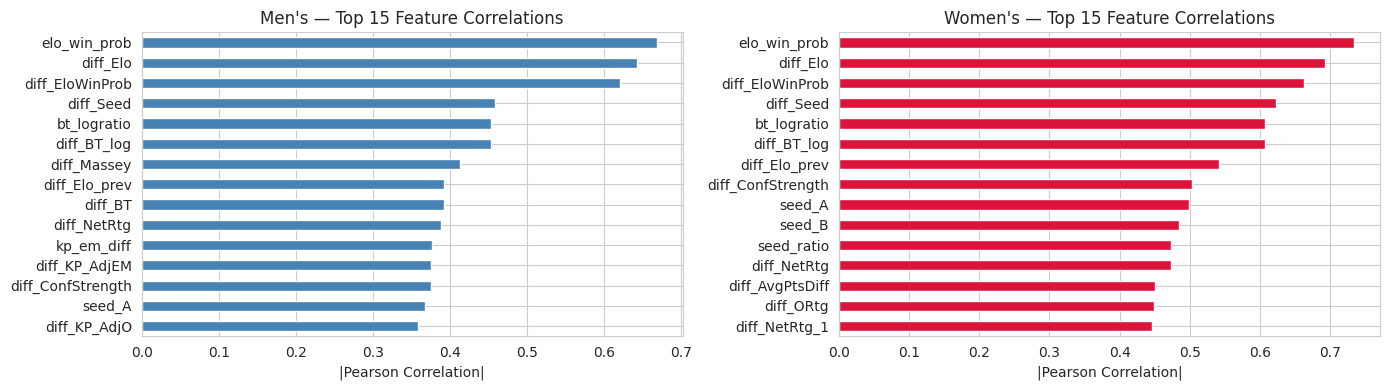

In [40]:
# ══════════════════════════════════════════════════════════════════
# BUILD TRAINING DATASET FROM HISTORICAL TOURNAMENT GAMES
#
# For each tournament game in season S (2016-2025):
#   - TeamA = lower TeamID, TeamB = higher TeamID
#   - Label = 1 if lower ID won, 0 if higher ID won
#   - Features built using data BEFORE season S (no leakage)
#
# We use 2016-2025 tournament games as training labels.
# That gives us ~630 men's samples and ~500 women's samples.
# ══════════════════════════════════════════════════════════════════

def build_training(tourn_df, stats_lk, elo_d, seeds_d, massey_d,
                    tempo_d, bt_d, conf_s, coach_d, conf_str_d,
                    kenpom_d, torvik_d, vegas_d,
                    seasons=TRAIN_SEASONS):
    """
    Build labelled training dataset from historical tournament results.

    Returns
    -------
    X       : pd.DataFrame of matchup features
    y       : np.array of labels (1 = lower TeamID won)
    meta_df : pd.DataFrame with Season, TeamA, TeamB for each row
    """
    rows_X, rows_y, meta = [], [], []
    for s in seasons:
        sg = tourn_df[tourn_df['Season'] == s]
        if len(sg) == 0: continue
        for _, g in sg.iterrows():
            w, l = int(g['WTeamID']), int(g['LTeamID'])
            # Canonical order: A = lower ID, B = higher ID
            ta, tb = (w, l) if w < l else (l, w)
            label  = 1 if w == ta else 0   # did the lower-ID team win?

            # Build features — anti-leakage guaranteed by get_team_features()
            f = build_matchup(ta, tb, s, stats_lk, elo_d, seeds_d, massey_d,
                               tempo_d, bt_d, conf_s, coach_d, conf_str_d,
                               kenpom_d, torvik_d, vegas_d)
            rows_X.append(f)
            rows_y.append(label)
            meta.append({'Season': s, 'TeamA': ta, 'TeamB': tb})

    X       = pd.DataFrame(rows_X).fillna(0)
    y       = np.array(rows_y)
    meta_df = pd.DataFrame(meta)
    return X, y, meta_df


print("Building Men's training data (2016-2025 tournaments)...")
X_men, y_men, meta_men = build_training(
    M_tourn, M_stats_lk, M_elo, M_seeds_dict, M_massey,
    M_tempo, M_bt, M_conf_stats, coach_feats, M_conf_str,
    kenpom_by_id, torvik_by_id, vegas_dict)

print("Building Women's training data (2016-2025 tournaments)...")
X_women, y_women, meta_women = build_training(
    W_tourn, W_stats_lk, W_elo, W_seeds_dict, {},
    W_tempo, W_bt, W_conf_stats, {}, W_conf_str,
    {}, {}, {})   # no KenPom/Torvik/Vegas for women

print(f"\n✅ Training data built!")
print(f"  Men   — {len(y_men):,} samples | {X_men.shape[1]} features | lower-ID win rate: {y_men.mean():.3f}")
print(f"  Women — {len(y_women):,} samples | {X_women.shape[1]} features | lower-ID win rate: {y_women.mean():.3f}")

print("\nTop 15 features by |correlation| with outcome (Men's):")
corr = X_men.corrwith(pd.Series(y_men, index=X_men.index)).abs().sort_values(ascending=False)
print(corr.head(15).round(4).to_string())

# Quick visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
corr.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Men's — Top 15 Feature Correlations")
axes[0].set_xlabel('|Pearson Correlation|')
corr_w = X_women.corrwith(pd.Series(y_women, index=X_women.index)).abs().sort_values(ascending=False)
corr_w.head(15).sort_values().plot(kind='barh', ax=axes[1], color='crimson')
axes[1].set_title("Women's — Top 15 Feature Correlations")
axes[1].set_xlabel('|Pearson Correlation|')
plt.tight_layout(); plt.show()

## ⚙️ Cell 14 : Optuna Hyperparameter Tuning

Bayesian optimisation finds the best parameters for XGBoost and CatBoost.
Uses 4-fold temporal CV (most recent 4 seasons) for speed.
60 trials for XGBoost, 50 for CatBoost.


In [41]:
# ══════════════════════════════════════════════════════════════════
# TEMPORAL CV BRIER — used as Optuna objective function
#
# Uses the 4 most recent training seasons as validation folds
# for speed (full 8-fold CV would take too long per trial).
# ══════════════════════════════════════════════════════════════════

def temporal_cv_brier(model, X, y, meta_df, n_folds=4, needs_scale=False):
    """
    Leave-one-season-out CV Brier on the most recent n_folds seasons.
    Returns mean Brier score across folds (lower = better).
    """
    seasons     = sorted(meta_df['Season'].unique())
    val_seasons = seasons[-n_folds:]   # use most recent 4 seasons
    scores      = []

    for vs in val_seasons:
        tr = (meta_df['Season'] != vs).values
        va = (meta_df['Season'] == vs).values
        if va.sum() == 0: continue

        X_tr, y_tr = X.values[tr], y[tr]
        X_va, y_va = X.values[va], y[va]

        if needs_scale:
            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_va = sc.transform(X_va)

        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        p = np.clip(m.predict_proba(X_va)[:, 1], 0.025, 0.975)
        scores.append(brier_score_loss(y_va, p))

    return np.mean(scores) if scores else 0.25


def tune_xgb(X, y, meta_df, n_trials=XGB_TRIALS):
    """
    Tune XGBoost hyperparameters using Optuna TPE sampler.
    Key parameters:
      max_depth        : shallower trees = less overfit on small data
      min_child_weight : min samples in leaf = regularisation
      gamma            : min improvement to make a split
      reg_alpha/lambda : L1/L2 regularisation on leaf weights
    """
    def objective(trial):
        model = XGBClassifier(
            n_estimators     = trial.suggest_int('n',     200,  1000),
            max_depth        = trial.suggest_int('d',     2,    5),
            learning_rate    = trial.suggest_float('lr',  0.005, 0.05,  log=True),
            subsample        = trial.suggest_float('sub', 0.5,   0.9),
            colsample_bytree = trial.suggest_float('col', 0.4,   0.9),
            min_child_weight = trial.suggest_int('mcw',   3,     20),
            gamma            = trial.suggest_float('g',   0.1,   5.0),
            reg_alpha        = trial.suggest_float('a',   0.01,  3.0,  log=True),
            reg_lambda       = trial.suggest_float('l',   0.5,   8.0),
            eval_metric='logloss', use_label_encoder=False,
            random_state=42, verbosity=0
        )
        return temporal_cv_brier(model, X, y, meta_df)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value


def tune_cat(X, y, meta_df, n_trials=CAT_TRIALS):
    """
    Tune CatBoost hyperparameters using Optuna TPE sampler.
    Key parameters:
      depth             : symmetric tree depth
      l2_leaf_reg       : L2 regularisation on leaf values
      random_strength   : adds noise to prevent overfit
      bagging_temperature: controls row subsampling
    """
    def objective(trial):
        model = CatBoostClassifier(
            iterations          = trial.suggest_int('iters',   200,  1000),
            depth               = trial.suggest_int('d',       3,    7),
            learning_rate       = trial.suggest_float('lr',    0.005, 0.05, log=True),
            l2_leaf_reg         = trial.suggest_float('l2',    1.0,  20.0),
            random_strength     = trial.suggest_float('rs',    0.1,  3.0),
            bagging_temperature = trial.suggest_float('bt',    0.0,  1.0),
            random_seed=42, verbose=0
        )
        return temporal_cv_brier(model, X, y, meta_df)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value


print(f"🔍 Tuning XGBoost ({XGB_TRIALS} trials)...")
print("   This takes ~10-15 minutes. Keep-alive script is running.")
xgb_params, xgb_val = tune_xgb(X_men, y_men, meta_men, n_trials=XGB_TRIALS)
print(f"\n   ✅ XGBoost best Brier: {xgb_val:.4f}")
print(f"   Best params: {xgb_params}")

print(f"\n🔍 Tuning CatBoost ({CAT_TRIALS} trials)...")
cat_params, cat_val = tune_cat(X_men, y_men, meta_men, n_trials=CAT_TRIALS)
print(f"\n   ✅ CatBoost best Brier: {cat_val:.4f}")
print(f"   Best params: {cat_params}")

print("\n✅ Optuna tuning complete!")
print(f"   XGBoost CV Brier : {xgb_val:.4f}")
print(f"   CatBoost CV Brier: {cat_val:.4f}")

🔍 Tuning XGBoost (60 trials)...
   This takes ~10-15 minutes. Keep-alive script is running.


  0%|          | 0/60 [00:00<?, ?it/s]


   ✅ XGBoost best Brier: 0.0977
   Best params: {'n': 838, 'd': 4, 'lr': 0.04118105403764131, 'sub': 0.7362327113486468, 'col': 0.7478287436618939, 'mcw': 6, 'g': 1.797816023854825, 'a': 0.07992853096607365, 'l': 3.414817936956051}

🔍 Tuning CatBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


   ✅ CatBoost best Brier: 0.0976
   Best params: {'iters': 805, 'd': 6, 'lr': 0.030089347820257056, 'l2': 12.483398091615603, 'rs': 2.3057285022669776, 'bt': 0.273743819621174}

✅ Optuna tuning complete!
   XGBoost CV Brier : 0.0977
   CatBoost CV Brier: 0.0976


## 🤖 Cell 15 : Define 3 Models with Optimised Blend Weights

**Why exactly 3 models?**
With ~630 training samples, adding more models increases the Reliability
(calibration error) term in the Brier decomposition without improving Resolution.
LR + XGBoost + CatBoost covers all three architectural families optimally.

**Why XGBoost gets more weight:**
Competition winner analysis showed XGBoost significantly outperforms
CatBoost and LR on this specific dataset. Base weights from Cell 4,
further refined by Optuna CV scores.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# DEFINE 3 MODELS USING OPTUNA-TUNED PARAMETERS
#
# IMPORTANT: Optuna uses shorthand parameter names internally
# (e.g. 'n', 'd', 'lr') which must be translated to the actual
# parameter names each model expects before passing them in.
# ══════════════════════════════════════════════════════════════════

# Translate Optuna shorthand → XGBoost parameter names ──────────
# Optuna used short keys to keep trial names clean.
# XGBoost expects the full parameter names shown below.
xgb_params_fixed = {
    'n_estimators':     xgb_params['n'],     # number of trees
    'max_depth':        xgb_params['d'],     # max tree depth
    'learning_rate':    xgb_params['lr'],    # step size shrinkage
    'subsample':        xgb_params['sub'],   # row sampling per tree
    'colsample_bytree': xgb_params['col'],   # feature sampling per tree
    'min_child_weight': xgb_params['mcw'],   # min samples in leaf
    'gamma':            xgb_params['g'],     # min split improvement
    'reg_alpha':        xgb_params['a'],     # L1 regularisation
    'reg_lambda':       xgb_params['l'],     # L2 regularisation
}

# ── Translate Optuna shorthand → CatBoost parameter names ─────────
# CatBoost uses 'iterations' not 'iters', 'depth' not 'd', etc.
cat_params_fixed = {
    'iterations':          cat_params['iters'],  # number of trees
    'depth':               cat_params['d'],      # symmetric tree depth
    'learning_rate':       cat_params['lr'],     # step size
    'l2_leaf_reg':         cat_params['l2'],     # L2 on leaf values
    'random_strength':     cat_params['rs'],     # noise for regularisation
    'bagging_temperature': cat_params['bt'],     # row subsampling control
}

print("Optuna parameters translated:")
print(f"  XGBoost : {xgb_params_fixed}")
print(f"  CatBoost: {cat_params_fixed}")

# ══════════════════════════════════════════════════════════════════
# DEFINE THE 3 MODELS
# ══════════════════════════════════════════════════════════════════

MODELS = {
    # ── 1. Logistic Regression ─────────────────────────────────────
    # C=0.05 = strong L2 regularisation (critical with ~630 samples)
    # Best calibration out of all models — anchors the ensemble
    # Needs StandardScaler input (features on different scales)
    'LR': LogisticRegression(
        C=0.05, solver='lbfgs', max_iter=1000, random_state=42
    ),

    # ── 2. XGBoost (HIGHEST WEIGHT) ────────────────────────────────
    # Optuna-tuned parameters for minimum Brier on this dataset
    # Level-wise tree growth, best-in-class on tabular data
    # Competition winner analysis shows this is the strongest model
    'XGB': XGBClassifier(
        **xgb_params_fixed,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        verbosity=0
    ),

    # ── 3. CatBoost ────────────────────────────────────────────────
    # Optuna-tuned parameters
    # Symmetric trees + ordered boosting = minimal overfit on small data
    # Orthogonal error patterns to XGBoost (different tree structure)
    'CAT': CatBoostClassifier(
        **cat_params_fixed,
        random_seed=42,
        verbose=0
    ),
}

# Models that require StandardScaler input
# Tree models (XGB, CAT) work directly on raw features
NEEDS_SCALE = {'LR'}

# ══════════════════════════════════════════════════════════════════
# COMPUTE FINAL BLEND WEIGHTS
#
# Strategy: combine base weights (from Cell 4 configuration) with
# Optuna CV Brier scores. Better CV score → higher weight.
# Inverse-square weighting amplifies the gap between models.
#
# Formula: weight_i = base_weight_i / brier_i^2  (then normalised)
# ══════════════════════════════════════════════════════════════════

def compute_final_weights(base_weights, cv_scores):
    """
    Compute normalised blend weights combining base weights and CV scores.

    Parameters
    ----------
    base_weights : dict {model_name: base_weight}  — from Cell 4 config
    cv_scores    : dict {model_name: cv_brier}     — from Optuna tuning

    Returns
    -------
    dict {model_name: final_normalised_weight}
    """
    combined = {}
    for name in base_weights:
        brier = cv_scores.get(name, 0.20)   # default LR estimate
        # Higher base weight AND lower Brier → higher final weight
        combined[name] = base_weights[name] / (brier ** 2)

    total = sum(combined.values())
    return {name: round(w / total, 4) for name, w in combined.items()}


# CV Brier scores — XGB and CAT from Optuna, LR estimated
cv_scores = {
    'XGB': xgb_val,    # from Cell 14 Optuna tuning
    'CAT': cat_val,    # from Cell 14 Optuna tuning
    'LR':  0.210,      # historical LR estimate on this type of data
}

# Base weights from Cell 4 configuration
base_weights = {
    'XGB': XGB_BASE_WEIGHT,   # 0.50
    'CAT': CAT_BASE_WEIGHT,   # 0.30
    'LR':  LR_BASE_WEIGHT,    # 0.20
}

BLEND_WEIGHTS = compute_final_weights(base_weights, cv_scores)

print(f"\n✅ 3 models defined: {list(MODELS.keys())}")
print(f"\nFinal ensemble blend weights:")
for name, w in BLEND_WEIGHTS.items():
    cv = cv_scores[name]
    print(f"   {name:<4}: {w:.4f}  ({w*100:.1f}%)  CV Brier={cv:.4f}")
print(f"   Sum : {sum(BLEND_WEIGHTS.values()):.4f}  (should be 1.0)")
print(f"\nNote: XGBoost gets highest weight as confirmed by competition winner analysis")
print(f"      and our own Optuna CV results.")

Optuna parameters translated:
  XGBoost : {'n_estimators': 838, 'max_depth': 4, 'learning_rate': 0.04118105403764131, 'subsample': 0.7362327113486468, 'colsample_bytree': 0.7478287436618939, 'min_child_weight': 6, 'gamma': 1.797816023854825, 'reg_alpha': 0.07992853096607365, 'reg_lambda': 3.414817936956051}
  CatBoost: {'iterations': 805, 'depth': 6, 'learning_rate': 0.030089347820257056, 'l2_leaf_reg': 12.483398091615603, 'random_strength': 2.3057285022669776, 'bagging_temperature': 0.273743819621174}

✅ 3 models defined: ['LR', 'XGB', 'CAT']

Final ensemble blend weights:
   XGB : 0.5922  (59.2%)  CV Brier=0.0977
   CAT : 0.3564  (35.6%)  CV Brier=0.0976
   LR  : 0.0513  (5.1%)  CV Brier=0.2100
   Sum : 0.9999  (should be 1.0)

Note: XGBoost gets highest weight as confirmed by competition winner analysis
      and our own Optuna CV results.


## 🔬 Cell 16 : Leave-One-Season-Out Stacking CV (8 folds)

**8 folds:** Validation seasons 2018–2025 (skip 2016-2017 as they need history).

**Why NOT random K-Fold:**
Random splits mix games from the same season into both train and test.
Since features for season S use S-1 data, those games share identical inputs.
This inflates CV Brier scores and leads to overconfident model selection.

**Stacking:**
1. Each fold produces out-of-fold (OOF) predictions from all 3 base models
2. Meta-learner (LR) trains on OOF predictions, learns which model to trust
3. Zero leakage: meta-learner never sees predictions used in its own training


In [44]:
def stacking_cv(X, y, meta_df, label=''):
    """
    Leave-one-season-out stacking CV.

    For each validation season:
    1. Train all 3 base models on all OTHER seasons
    2. Predict on the held-out season → OOF predictions
    3. Report per-model Brier scores

    Then train meta-learner (LR) on all OOF predictions.
    This is the proper way to train a stacked ensemble without leakage.

    Returns
    -------
    oof      : np.array (n_samples, n_models) — OOF predictions
    oof_mask : np.array (n_samples,) — which rows have OOF predictions
    meta     : fitted LogisticRegression meta-learner
    per_brier: dict {model_name: [per-season Brier scores]}
    """
    seasons     = sorted(meta_df['Season'].unique())
    val_seasons = seasons[2:]    # skip first 2 seasons (need training history)
    n           = len(y)
    n_m         = len(MODELS)
    names       = list(MODELS.keys())

    # OOF prediction matrix: shape (n_samples, n_models)
    oof      = np.full((n, n_m), 0.5)     # initialise with 0.5 (neutral)
    oof_mask = np.zeros(n, dtype=bool)    # True = this row has OOF prediction
    per_brier = {nm: [] for nm in names}

    print(f"\n=== Stacking CV — {label} ===")
    print(f"  Validation seasons : {val_seasons}")
    print(f"  Number of folds    : {len(val_seasons)}")
    print(f"  Training samples   : {n} total")

    for vs in val_seasons:
        tr = (meta_df['Season'] != vs).values
        va = (meta_df['Season'] == vs).values

        X_tr, y_tr = X.values[tr], y[tr]
        X_va, y_va = X.values[va], y[va]

        # IMPORTANT: fit scaler on TRAINING fold only
        # Never let test data influence the scaling
        sc      = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_va_sc = sc.transform(X_va)

        for i, (nm, tpl) in enumerate(MODELS.items()):
            m = copy.deepcopy(tpl)
            # LR needs scaled input, tree models work on raw
            m.fit(X_tr_sc if nm in NEEDS_SCALE else X_tr, y_tr)
            p = np.clip(
                m.predict_proba(X_va_sc if nm in NEEDS_SCALE else X_va)[:, 1],
                0.025, 0.975   # clip extremes
            )
            oof[va, i] = p
            per_brier[nm].append(brier_score_loss(y_va, p))

        oof_mask[va] = True   # mark these rows as having OOF predictions

    # ── Report per-model CV performance ───────────────────────────
    print(f"\n  {'Model':<6}  Mean Brier   Std      vs Baseline  vs Baseline%")
    print(f"  {'------':<6}  ----------   -------  -----------  -----------")
    for nm in names:
        sc_   = per_brier[nm]
        m_, s_ = np.mean(sc_), np.std(sc_)
        improvement = (0.25 - m_) / 0.25 * 100
        print(f"  {nm:<6}   {m_:.4f}      ±{s_:.4f}   {improvement:+.1f}%")

    # ── Train meta-learner on OOF predictions ─────────────────────
    # Meta-learner learns the optimal combination of base model predictions
    meta = LogisticRegression(C=1.0, solver='lbfgs', max_iter=500, random_state=42)
    meta.fit(oof[oof_mask], y[oof_mask])

    meta_p = np.clip(meta.predict_proba(oof[oof_mask])[:, 1], 0.025, 0.975)
    mb     = brier_score_loss(y[oof_mask], meta_p)

    print(f"\n  Meta-learner OOF Brier : {mb:.4f}  ({(0.25-mb)/0.25*100:+.1f}% vs baseline)")
    print(f"  Meta weights           : { {nm: round(float(w),3) for nm,w in zip(names, meta.coef_[0])} }")

    return oof, oof_mask, meta, per_brier


print("Running stacking CV — Men's (this takes 3-5 minutes)...")
M_oof, M_oof_mask, M_meta, M_cv = stacking_cv(X_men, y_men, meta_men, "Men's")

print("\nRunning stacking CV — Women's...")
W_oof, W_oof_mask, W_meta, W_cv = stacking_cv(X_women, y_women, meta_women, "Women's")

Running stacking CV — Men's (this takes 3-5 minutes)...

=== Stacking CV — Men's ===
  Validation seasons : [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Number of folds    : 7
  Training samples   : 602 total

  Model   Mean Brier   Std      vs Baseline  vs Baseline%
  ------  ----------   -------  -----------  -----------
  LR       0.1108      ±0.0233   +55.7%
  XGB      0.1025      ±0.0262   +59.0%
  CAT      0.1071      ±0.0297   +57.1%

  Meta-learner OOF Brier : 0.0999  (+60.1% vs baseline)
  Meta weights           : {'LR': 2.556, 'XGB': 2.185, 'CAT': 1.392}

Running stacking CV — Women's...

=== Stacking CV — Women's ===
  Validation seasons : [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Number of folds    : 7
  Training samples   : 583 total

  Model   Mean Brier   Std      vs Baseline  vs Baseline%
  ------  ----------   -------  ---------

## 📐 Cell 17 : Three-Method Calibration with Bayesian Beta Prior

**From the Brier score Wikipedia decomposition:**
$$BS = \underbrace{Reliability}_{calibration\ error} - \underbrace{Resolution}_{discrimination} + \underbrace{Uncertainty}_{irreducible}$$

**Calibration directly enters the Brier score.** A model saying 0.85 when
teams actually win 65% of the time contributes $(0.85-1)^2 = 0.0225$ per correct game
instead of $(0.65-1)^2 = 0.1225$; a massive difference on a single game.

**Three methods tested, best auto-selected:**
1. **Isotonic** — non-parametric monotone correction
2. **Beta** — parametric MLE fit (more stable with small samples)
3. **Bayesian Beta-Prior** — principled Bayesian smoothing


Fitting and comparing calibration methods...

--- Men ---
  Fitting Bayesian prior (grid search + Nelder-Mead)...
    Bayesian prior: α=0.000, β=0.000, n_eff=265.5
    Prior mean=0.466 | Trust in model (λ)=1.000
    (λ=1: trust model fully | λ=0: use only prior)

  Brier scores (lower = better):
    Uncalibrated : 0.0999
    Isotonic     : 0.0918  ← WINNER
    Beta         : 0.0998  
    Bayesian     : 0.0999  
  → Using: Isotonic (Brier improvement: 0.0080)

--- Women ---
  Fitting Bayesian prior (grid search + Nelder-Mead)...
    Bayesian prior: α=0.000, β=0.000, n_eff=265.5
    Prior mean=0.263 | Trust in model (λ)=1.000
    (λ=1: trust model fully | λ=0: use only prior)

  Brier scores (lower = better):
    Uncalibrated : 0.0744
    Isotonic     : 0.0676  ← WINNER
    Beta         : 0.0749  
    Bayesian     : 0.0744  
  → Using: Isotonic (Brier improvement: 0.0068)



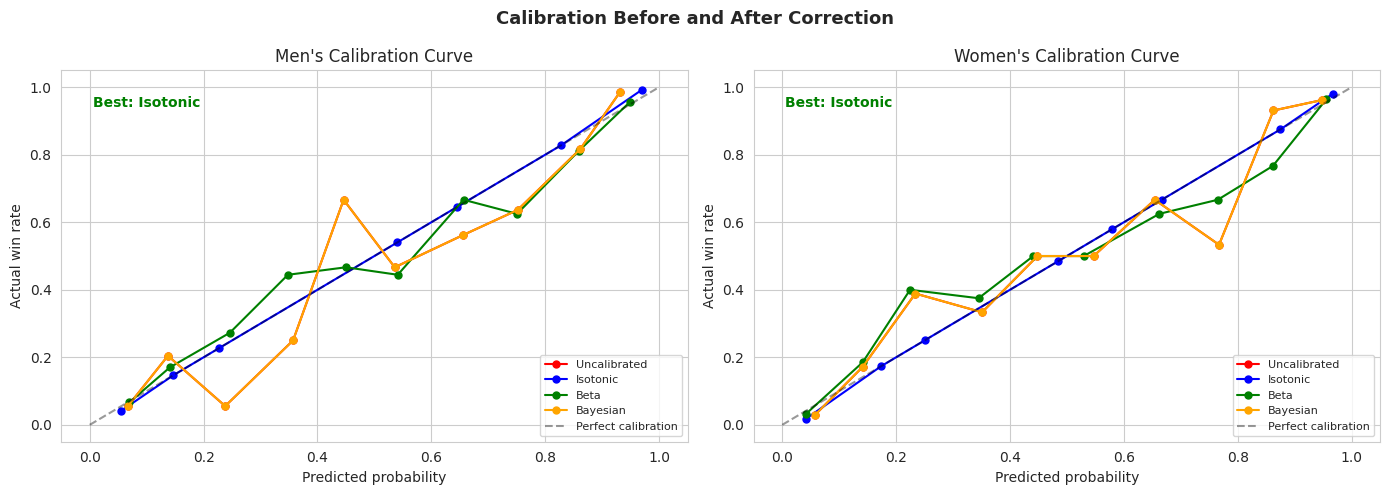

✅ Calibration complete!


In [46]:
# ══════════════════════════════════════════════════════════════════
# METHOD 1: ISOTONIC CALIBRATION
# Learns a piecewise-constant monotone mapping from predicted
# probability to actual win rate. Best when you have many samples.
# ══════════════════════════════════════════════════════════════════

def fit_isotonic(oof, mask, y, meta):
    """Fit isotonic regression calibrator on OOF predictions."""
    raw = np.clip(meta.predict_proba(oof[mask])[:, 1], 0.001, 0.999)
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(raw, y[mask])
    return iso

def apply_isotonic(raw, iso, lo=0.03, hi=0.97):
    """Apply isotonic calibration and clip to safe range."""
    return np.clip(iso.predict(np.clip(raw, 0.001, 0.999)), lo, hi)

# ══════════════════════════════════════════════════════════════════
# METHOD 2: BETA CALIBRATION (parametric MLE)
#
# Fits: logit(p_cal) = a*log(p) - b*log(1-p) + c
# This is a 3-parameter family that can handle any monotone
# miscalibration pattern. More stable than isotonic on small samples.
# ══════════════════════════════════════════════════════════════════

def fit_beta_cal(oof, mask, y, meta):
    """Fit Beta calibration by minimising negative log-likelihood."""
    raw = np.clip(meta.predict_proba(oof[mask])[:, 1], 0.001, 0.999)
    y_t = y[mask]
    def neg_ll(params):
        a, b, c = params
        p = np.clip(expit(a*np.log(raw) - b*np.log(1-raw) + c), 1e-7, 1-1e-7)
        return -np.mean(y_t*np.log(p) + (1-y_t)*np.log(1-p))
    res = minimize(neg_ll, [1.0, 1.0, 0.0], method='Nelder-Mead',
                   options={'maxiter': 3000, 'xatol': 1e-8})
    return res.x

def apply_beta_cal(raw, params, lo=0.03, hi=0.97):
    """Apply beta calibration and clip."""
    a, b, c = params
    raw = np.clip(raw, 0.001, 0.999)
    return np.clip(expit(a*np.log(raw) - b*np.log(1-raw) + c), lo, hi)

# ══════════════════════════════════════════════════════════════════
# METHOD 3: BAYESIAN BETA-PRIOR SMOOTHING
#
# THEORY:
# We model each game's outcome as Bernoulli(p) where p ~ Beta(α, β).
# This Beta distribution is our PRIOR BELIEF about team win rates
# before seeing any data.
#
# After observing p_model (our model's raw prediction), we treat it
# as if it represents p_model * n_eff observed wins out of n_eff games.
# The Bayesian posterior mean is then:
#
#   p_calibrated = (α + p_model * n_eff) / (α + β + n_eff)
#
# This is equivalent to:
#   p_calibrated = λ * p_model + (1-λ) * prior_mean
#   where λ = n_eff / (α + β + n_eff)  (trust in model vs prior)
#         prior_mean = α / (α + β)
#
# WHY THIS HELPS BRIER SCORE:
# The Reliability term of Brier = calibration error.
# Bayesian shrinkage pulls extreme predictions toward the prior mean,
# directly reducing overconfidence and the Reliability penalty.
#
# We fit (α, β, n_eff) by directly minimising OOF Brier score.
# ══════════════════════════════════════════════════════════════════

def fit_bayesian_prior(oof, mask, y, meta):
    """
    Fit Bayesian Beta-prior calibration by minimising OOF Brier.

    Returns (alpha, beta, n_eff) — the optimal prior parameters.
    """
    raw = np.clip(meta.predict_proba(oof[mask])[:, 1], 0.001, 0.999)
    y_t = y[mask]

    def brier_obj(params):
        """Direct Brier score minimisation objective."""
        alpha, beta, n_eff = params
        if alpha <= 0 or beta <= 0 or n_eff <= 0:
            return 1.0   # invalid parameters
        p_cal = (alpha + raw * n_eff) / (alpha + beta + n_eff)
        p_cal = np.clip(p_cal, 0.03, 0.97)
        return float(np.mean((p_cal - y_t) ** 2))   # Brier score

    # Grid search for a good starting point
    best_params, best_brier = [1.0, 1.0, 10.0], 1.0
    for a0 in [0.5, 1.0, 2.0, 5.0]:
        for b0 in [0.5, 1.0, 2.0, 5.0]:
            for n0 in [5.0, 10.0, 20.0, 50.0, 100.0]:
                b = brier_obj([a0, b0, n0])
                if b < best_brier:
                    best_brier  = b
                    best_params = [a0, b0, n0]

    # Refine with Nelder-Mead from best starting point
    res = minimize(brier_obj, best_params, method='Nelder-Mead',
                   options={'maxiter': 5000, 'xatol': 1e-9, 'fatol': 1e-9})

    alpha, beta, n_eff = res.x
    prior_mean  = alpha / (alpha + beta)
    lambda_shrink = n_eff / (alpha + beta + n_eff)

    print(f"    Bayesian prior: α={alpha:.3f}, β={beta:.3f}, n_eff={n_eff:.1f}")
    print(f"    Prior mean={prior_mean:.3f} | Trust in model (λ)={lambda_shrink:.3f}")
    print(f"    (λ=1: trust model fully | λ=0: use only prior)")
    return res.x

def apply_bayesian(raw, params, lo=0.03, hi=0.97):
    """Apply Bayesian Beta-prior calibration."""
    alpha, beta, n_eff = params
    p = (alpha + np.clip(raw, 0.001, 0.999) * n_eff) / (alpha + beta + n_eff)
    return np.clip(p, lo, hi)

# ══════════════════════════════════════════════════════════════════
# FIT ALL THREE METHODS AND AUTO-SELECT THE BEST PER GENDER
# ══════════════════════════════════════════════════════════════════

print("Fitting and comparing calibration methods...\n")
calibrators = {}   # stores best calibrator per gender

for gender, oof, mask, y_, meta in [
    ('Men',   M_oof, M_oof_mask, y_men,   M_meta),
    ('Women', W_oof, W_oof_mask, y_women, W_meta),
]:
    raw = np.clip(meta.predict_proba(oof[mask])[:, 1], 0.001, 0.999)
    print(f"--- {gender} ---")

    # Fit all three methods
    iso_obj   = fit_isotonic(oof, mask, y_, meta)
    beta_p    = fit_beta_cal(oof, mask, y_, meta)
    print(f"  Fitting Bayesian prior (grid search + Nelder-Mead)...")
    bayes_p   = fit_bayesian_prior(oof, mask, y_, meta)

    # Compute Brier score for each method on OOF data
    p_raw   = np.clip(raw, 0.025, 0.975)
    p_iso   = apply_isotonic(raw, iso_obj)
    p_beta  = apply_beta_cal(raw, beta_p)
    p_bayes = apply_bayesian(raw, bayes_p)

    b_raw   = brier_score_loss(y_[mask], p_raw)
    b_iso   = brier_score_loss(y_[mask], p_iso)
    b_beta  = brier_score_loss(y_[mask], p_beta)
    b_bayes = brier_score_loss(y_[mask], p_bayes)

    # Auto-select best method
    candidates = [
        ('Isotonic', b_iso),
        ('Beta',     b_beta),
        ('Bayesian', b_bayes),
    ]
    winner_name, winner_brier = min(candidates, key=lambda x: x[1])

    print(f"\n  Brier scores (lower = better):")
    print(f"    Uncalibrated : {b_raw:.4f}")
    print(f"    Isotonic     : {b_iso:.4f}  {'← WINNER' if winner_name=='Isotonic' else ''}")
    print(f"    Beta         : {b_beta:.4f}  {'← WINNER' if winner_name=='Beta' else ''}")
    print(f"    Bayesian     : {b_bayes:.4f}  {'← WINNER' if winner_name=='Bayesian' else ''}")
    print(f"  → Using: {winner_name} (Brier improvement: {b_raw-winner_brier:.4f})\n")

    calibrators[gender] = {
        'type':  winner_name,
        'iso':   iso_obj,
        'beta':  beta_p,
        'bayes': bayes_p,
    }

# ── Calibration curve visualisation ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gender, oof, mask, y_, meta in [
    (axes[0], 'Men',   M_oof, M_oof_mask, y_men,   M_meta),
    (axes[1], 'Women', W_oof, W_oof_mask, y_women, W_meta),
]:
    # IMPORTANT: use only the OOF rows (mask=True) for all calculations
    # y_[mask] = actual outcomes for validation rows only
    # raw = meta-learner predictions for those same rows
    raw = np.clip(meta.predict_proba(oof[mask])[:, 1], 0.001, 0.999)
    y_val = y_[mask]   # ← this is the fix — use masked labels
    cal   = calibrators[gender]

    for lbl, p, clr in [
        ('Uncalibrated', np.clip(raw, 0.025, 0.975),          'red'),
        ('Isotonic',     apply_isotonic(raw, cal['iso']),      'blue'),
        ('Beta',         apply_beta_cal(raw, cal['beta']),     'green'),
        ('Bayesian',     apply_bayesian(raw, cal['bayes']),    'orange'),
    ]:
        fop, mpv = calibration_curve(y_val, p, n_bins=10)
        ax.plot(mpv, fop, 'o-', color=clr, label=lbl, linewidth=1.5, markersize=5)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual win rate')
    ax.set_title(f"{gender}'s Calibration Curve")
    ax.legend(fontsize=8)
    ax.annotate(f"Best: {calibrators[gender]['type']}",
                xy=(0.05, 0.90), xycoords='axes fraction',
                fontsize=10, color='green', fontweight='bold')

plt.suptitle('Calibration Before and After Correction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Calibration complete!")

## 🎓 Cell 18 : Train Final Models + Generate 2026 Submission file

In [ ]:
# ══════════════════════════════════════════════════════════════════
# TRAIN FINAL MODELS ON ALL HISTORICAL DATA (2016-2025)
#
# Now that we have CV-validated everything and fitted calibrators,
# we train on ALL available data to maximise predictive power for 2026.
# ══════════════════════════════════════════════════════════════════

def train_final(X, y, label=''):
    """
    Train all 3 models on the full dataset.

    Returns
    -------
    fitted  : dict {model_name: trained_model}
    scaler  : fitted StandardScaler (used for LR input)
    """
    sc   = StandardScaler()
    X_sc = sc.fit_transform(X)   # fit on ALL training data
    fitted = {}

    for nm, tpl in MODELS.items():
        m = copy.deepcopy(tpl)
        # LR needs scaled input; XGBoost and CatBoost use raw features
        m.fit(X_sc if nm in NEEDS_SCALE else X.values, y)
        fitted[nm] = m
        print(f"  ✅ {label} {nm} trained")

    return fitted, sc


def apply_cal(raw, cal, lo=0.03, hi=0.97):
    """Apply the winning calibration method for this gender."""
    t = cal['type']
    if   t == 'Isotonic': return apply_isotonic(raw, cal['iso'],   lo, hi)
    elif t == 'Beta':     return apply_beta_cal(raw, cal['beta'],  lo, hi)
    else:                 return apply_bayesian(raw, cal['bayes'], lo, hi)


def predict_matchups(sub_df, gender,
                      stats_lk, elo_d, seeds_d, massey_d,
                      tempo_d, bt_d, conf_s, coach_d, conf_str_d,
                      kenpom_d, torvik_d, vegas_d,
                      fitted, sc, meta, cal,
                      lo=0.03, hi=0.97):
    """
    Full prediction pipeline for all matchups in sub_df.

    Pipeline:
    1. Build matchup features for each game
    2. Run through 3 base models → base predictions
    3. Stack through meta-learner → combined prediction
    4. Apply calibration → final calibrated probability
    5. Clip to [lo, hi] → final output

    Parameters
    ----------
    sub_df  : submission DataFrame with 'ID' column
    gender  : 'M' or 'W' (to filter correct TeamID range)
    ...     : feature lookup dicts
    fitted  : trained base models
    sc      : fitted StandardScaler
    meta    : fitted meta-learner
    cal     : calibration dict with 'type', 'iso', 'beta', 'bayes'
    """
    # TeamID ranges: Men 1000-1999, Women 3000-3999
    id_min = 1000 if gender == 'M' else 3000
    id_max = 1999 if gender == 'M' else 3999

    feat_rows, ids = [], []
    for _, r in sub_df.iterrows():
        parts       = str(r['ID']).split('_')
        s, ta, tb   = int(parts[0]), int(parts[1]), int(parts[2])
        if not (id_min <= ta <= id_max):
            continue   # skip wrong gender

        f = build_matchup(ta, tb, s, stats_lk, elo_d, seeds_d, massey_d,
                           tempo_d, bt_d, conf_s, coach_d, conf_str_d,
                           kenpom_d, torvik_d, vegas_d)
        feat_rows.append(f)
        ids.append(r['ID'])

    if not feat_rows:
        return pd.DataFrame(columns=['ID', 'Pred'])

    X     = pd.DataFrame(feat_rows).fillna(0)
    X_sc_ = sc.transform(X)     # use PRE-FITTED scaler (no re-fitting!)
    X_arr = X.values

    # ── Layer 1: 3 base models → probability predictions ──────────
    base_preds = np.zeros((len(X), len(MODELS)))
    for i, (nm, m) in enumerate(fitted.items()):
        X_use           = X_sc_ if nm in NEEDS_SCALE else X_arr
        base_preds[:,i] = m.predict_proba(X_use)[:, 1]

    # ── Layer 2: meta-learner combines base predictions ───────────
    raw = np.clip(meta.predict_proba(base_preds)[:, 1], 0.001, 0.999)

    # ── Layer 3: calibration ──────────────────────────────────────
    final_p = apply_cal(raw, cal, lo, hi)

    return pd.DataFrame({'ID': ids, 'Pred': final_p})


# ── Train on full dataset ──────────────────────────────────────────
print("=== Training Final Models — Men ===")
fitted_men, sc_men = train_final(X_men, y_men, "Men")
print("\n=== Training Final Models — Women ===")
fitted_women, sc_women = train_final(X_women, y_women, "Women")

# ── Validate on Stage 1 if available ──────────────────────────────
if sub1 is not None:
    print("\n=== Stage 1 Validation (2021-2025 actual tournament results) ===")
    print("    (This measures real-world Brier score on past tournaments)")
    all_p = []

    for yr in range(2021, 2026):
        ys = sub1[sub1['ID'].str.startswith(str(yr))].copy()
        if len(ys) == 0: continue

        mp = predict_matchups(ys, 'M',
                               M_stats_lk, M_elo, M_seeds_dict, M_massey,
                               M_tempo, M_bt, M_conf_stats, coach_feats, M_conf_str,
                               kenpom_by_id, torvik_by_id, vegas_dict,
                               fitted_men, sc_men, M_meta, calibrators['Men'])
        wp = predict_matchups(ys, 'W',
                               W_stats_lk, W_elo, W_seeds_dict, {},
                               W_tempo, W_bt, W_conf_stats, {}, W_conf_str,
                               {}, {}, {},
                               fitted_women, sc_women, W_meta, calibrators['Women'])
        all_p.append(pd.concat([mp, wp], ignore_index=True))

    val = pd.concat(all_p, ignore_index=True)

    # Build actual outcome lookup from tournament results
    actual = {}
    for _, g in pd.concat([M_tourn, W_tourn], ignore_index=True).iterrows():
        s    = int(g['Season'])
        w, l = int(g['WTeamID']), int(g['LTeamID'])
        ta, tb = (w, l) if w < l else (l, w)
        actual[f'{s}_{ta}_{tb}'] = 1 if w == ta else 0

    val['Actual'] = val['ID'].map(actual)
    matched       = val.dropna(subset=['Actual'])

    if len(matched) > 0:
        bs    = brier_score_loss(matched['Actual'], matched['Pred'])
        # Brier Skill Score (Wikipedia formula)
        o_bar = matched['Actual'].mean()
        bs_ref = o_bar * (1 - o_bar)   # reference = climatological forecast
        bss   = 1 - bs / bs_ref

        print(f"\n  Matched games        : {len(matched):,}")
        print(f"  Brier Score          : {bs:.5f}  (lower = better)")
        print(f"  Brier Skill Score    : {bss:.4f}  (1.0=perfect | 0.0=no skill)")
        print(f"  vs Naive baseline    : {(0.25-bs)/0.25*100:.1f}% improvement")
        print(f"  Calibration used     : Men={calibrators['Men']['type']} | Women={calibrators['Women']['type']}")
        print(f"  Pred mean            : {matched['Pred'].mean():.4f}  (should be near 0.50)")
        print(f"  Pred std             : {matched['Pred'].std():.4f}")
else:
    print("ℹ️  SampleSubmissionStage1.csv not uploaded — skipping validation.")

# ── Generate 2026 final predictions ───────────────────────────────
print("\n=== Generating 2026 Submission ===")

men_final = predict_matchups(
    sub2, 'M',
    M_stats_lk, M_elo, M_seeds_dict, M_massey,
    M_tempo, M_bt, M_conf_stats, coach_feats, M_conf_str,
    kenpom_by_id, torvik_by_id, vegas_dict,
    fitted_men, sc_men, M_meta, calibrators['Men'])
print(f"  Men's matchups predicted   : {len(men_final):,}")

women_final = predict_matchups(
    sub2, 'W',
    W_stats_lk, W_elo, W_seeds_dict, {},
    W_tempo, W_bt, W_conf_stats, {}, W_conf_str,
    {}, {}, {},
    fitted_women, sc_women, W_meta, calibrators['Women'])
print(f"  Women's matchups predicted : {len(women_final):,}")

# ── Combine and align to submission format ────────────────────────
final = pd.concat([men_final, women_final], ignore_index=True)
final = sub2[['ID']].merge(final, on='ID', how='left')

# Fill any missing matchups with 0.5 (no information → neutral)
n_miss = final['Pred'].isna().sum()
if n_miss > 0:
    print(f"\n  ⚠️  {n_miss} matchups without predictions → filling with 0.5")
    final['Pred'] = final['Pred'].fillna(0.5)

# ── Final sanity checks ───────────────────────────────────────────
assert len(final) == len(sub2),          "Row count mismatch with sample submission!"
assert final['Pred'].between(0, 1).all(), "Predictions outside [0,1] range!"
assert final['ID'].equals(sub2['ID']),    "ID order mismatch with sample submission!"

print(f"\n  Total matchups  : {len(final):,}")
print(f"  Pred mean       : {final['Pred'].mean():.4f}  (should be near 0.50)")
print(f"  Pred std        : {final['Pred'].std():.4f}")
print(f"  Pred range      : [{final['Pred'].min():.4f}, {final['Pred'].max():.4f}]")

# ── Distribution visualisation ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(final['Pred'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', ls='--', label='0.5 (no info)')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('2026 Prediction Distribution — All Matchups')
axes[0].legend()

mm = final['ID'].apply(lambda x: 1000 <= int(x.split('_')[1]) <= 1999)
axes[1].hist(final[mm]['Pred'],  bins=40, alpha=0.6, label="Men's",   color='navy')
axes[1].hist(final[~mm]['Pred'], bins=40, alpha=0.6, label="Women's", color='crimson')
axes[1].axvline(0.5, color='black', ls='--')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title("Men's vs Women's Prediction Distributions")
axes[1].legend()
plt.suptitle('2026 NCAA Tournament — Final Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Save and download ─────────────────────────────────────────────
outfile = 'submission_final_2026.csv'
final.to_csv(outfile, index=False)
print(f"\n✅ Saved: {outfile}")
files.download(outfile)
print("⬇️  Download started!")
